# Modelo de originación crediticia y evaluación de proveedores externos

**Prueba técnica — Data Scientist Jr. · entidad financiera**

El ejercicio responde al lanzamiento de un producto de crédito dirigido a un segmento de
alto riesgo, donde una mala originación genera pérdidas materiales. Se abordan dos frentes:
construir un modelo interno de calificación con un punto de corte operable, y evaluar si
dos proveedores externos de scoring aportan capacidad discriminante real.

> **Nota sobre los datos.** El conjunto de datos es propiedad de la entidad que emitió la
> prueba y no se distribuye con este repositorio. El notebook documenta la metodología
> completa y reproduce todos los resultados a partir de esos insumos.

**Estructura:** carga y sanity check · estabilidad temporal y particionamiento · EDA y
auditoría de fugas · ingeniería de características · optimización y entrenamiento ·
evaluación out-of-time y punto de corte · auditoría SHAP y modelo V2 · evaluación de
proveedores · exportación de la curva de política.

--- Información General del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 4315 entries, 0 to 4314
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           4315 non-null   int64  
 1   FFECHA                       4315 non-null   int64  
 2   Mora30                       4315 non-null   int64  
 3   Mora60                       4315 non-null   int64  
 4   MoraMax_UltimoSemestre       4315 non-null   int64  
 5   ExperienciaSectorFinanciero  4315 non-null   int64  
 6   PersonasCargo                4315 non-null   int64  
 7   GastosFamiliares             4315 non-null   float64
 8   GastoArriendo                4315 non-null   int64  
 9   TiempoActividadAnios         4315 non-null   int64  
 10  OCUPACION                    4315 non-null   str    
 11  TIPCONTRATO                  4315 non-null   str    
 12  Edad                         4315 non-null   in

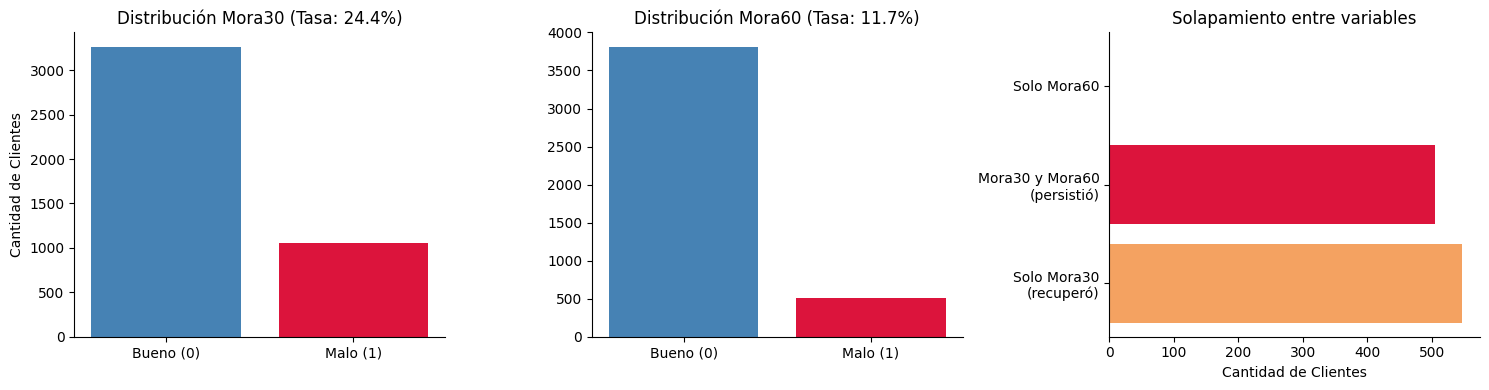


Variable objetivo seleccionada: Mora60

--- Análisis de Anomalías en TiempoActividadAnios ---
Top 5 valores más altos:
4269    866880
2467        72
4226        72
4071        42
710         32


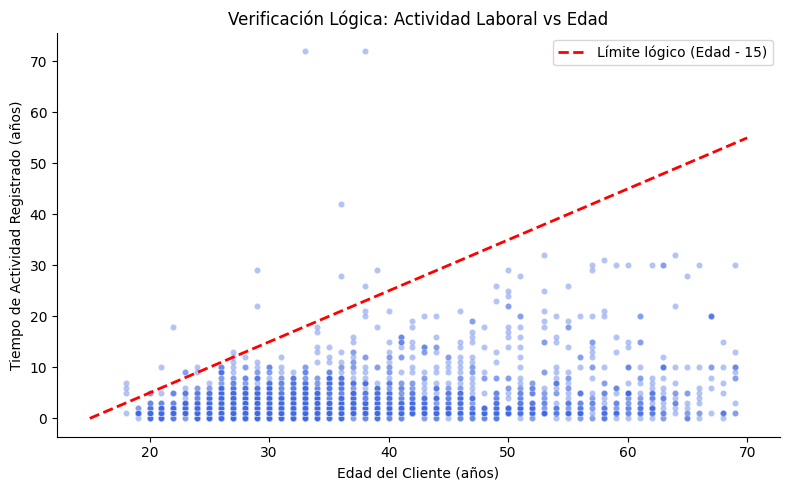

In [1]:
# ==============================================================================
# BLOQUE 1: CARGA DE DATOS Y SANITY CHECK
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1.1 Carga del dataset
# ------------------------------------------------------------------------------
ruta = r"../bases_datos/ProductoNuevo.xlsx"
df = pd.read_excel(ruta)

print("--- Información General del Dataset ---")
df.info()

# ------------------------------------------------------------------------------
# 1.2 Verificación de integridad
# ------------------------------------------------------------------------------
#Se valida unicidad de registros y presencia de nulos antes de cualquier
#transformación. Esto evita propagar problemas de calidad al pipeline.

duplicados_totales = df.duplicated().sum()
duplicados_id      = df['ID'].duplicated().sum()
nulos_por_columna  = df.isnull().sum()

print(f"\nFilas duplicadas totales : {duplicados_totales}")
print(f"IDs duplicados           : {duplicados_id}")

print("\nValores nulos por columna:")
if nulos_por_columna.sum() > 0:
    resumen_nulos = pd.DataFrame({
        'Nulos'  : nulos_por_columna,
        'Pct (%)': (nulos_por_columna / len(df) * 100).round(2)
    })
    print(resumen_nulos[resumen_nulos['Nulos'] > 0].to_string())
else:
    print("Sin valores nulos en ninguna columna.")

# ------------------------------------------------------------------------------
# 1.3 Formateo temporal
# ------------------------------------------------------------------------------
#FFECHA viene como entero YYYYMM. Se convierte a datetime para habilitar
#el particionamiento cronológico del Bloque 2.

df['FFECHA'] = pd.to_datetime(df['FFECHA'].astype(str), format='%Y%m')
df = df.sort_values('FFECHA').reset_index(drop=True)

print(f"\nRango temporal: {df['FFECHA'].min().strftime('%Y-%m')} → "
      f"{df['FFECHA'].max().strftime('%Y-%m')}")

# ------------------------------------------------------------------------------
# 1.4 Análisis comparativo de la variable objetivo: Mora30 vs Mora60
# ------------------------------------------------------------------------------
"""
Se cuantifica el solapamiento entre ambas variables para identificar
cuántos clientes que cayeron en Mora30 persistieron hasta Mora60.
Esta proporción es clave para decidir cuál variable representa mejor
el riesgo crediticio sostenido vs el ruido de eventos transitorios.
"""
print("\n--- Comparativa Mora30 vs Mora60 ---")
print(f"Tasa Mora30 : {df['Mora30'].mean()*100:.2f}%  ({df['Mora30'].sum()} casos)")
print(f"Tasa Mora60 : {df['Mora60'].mean()*100:.2f}%  ({df['Mora60'].sum()} casos)")
print(f"Correlación : {df['Mora30'].corr(df['Mora60']):.4f}")

# Cálculo del solapamiento entre ambas variables
mora30_set  = set(df[df['Mora30'] == 1].index)
mora60_set  = set(df[df['Mora60'] == 1].index)
solo_mora30 = len(mora30_set - mora60_set)
ambos       = len(mora30_set & mora60_set)
solo_mora60 = len(mora60_set - mora30_set)

# Visualización: distribuciones de ambas variables y su solapamiento
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['Bueno (0)', 'Malo (1)'],
            df['Mora30'].value_counts().sort_index().values,
            color=['steelblue', 'crimson'])
axes[0].set_title(f'Distribución Mora30 (Tasa: {df["Mora30"].mean()*100:.1f}%)')
axes[0].set_ylabel('Cantidad de Clientes')
sns.despine(ax=axes[0])

axes[1].bar(['Bueno (0)', 'Malo (1)'],
            df['Mora60'].value_counts().sort_index().values,
            color=['steelblue', 'crimson'])
axes[1].set_title(f'Distribución Mora60 (Tasa: {df["Mora60"].mean()*100:.1f}%)')
sns.despine(ax=axes[1])

axes[2].barh(['Solo Mora30\n(recuperó)',
              'Mora30 y Mora60\n(persistió)',
              'Solo Mora60'],
             [solo_mora30, ambos, solo_mora60],
             color=['#f4a261', 'crimson', '#264653'])
axes[2].set_title('Solapamiento entre variables')
axes[2].set_xlabel('Cantidad de Clientes')
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

# Decisión: se elige Mora60 como variable objetivo. Justificación detallada
# en presentación (estabilidad de la señal, estándar regulatorio, viabilidad).
print(f"\nVariable objetivo seleccionada: Mora60")

# ------------------------------------------------------------------------------
# 1.5 Análisis de anomalías en variables críticas
# ------------------------------------------------------------------------------
# Se inspeccionan valores extremos en TiempoActividadAnios para detectar
# errores de digitación e inconsistencias lógicas (experiencia laboral
# que excede la edad biológicamente posible).
print("\n--- Análisis de Anomalías en TiempoActividadAnios ---")
print("Top 5 valores más altos:")
print(df['TiempoActividadAnios'].nlargest(5).to_string())

# Visualización: Edad vs TiempoActividadAnios con frontera lógica
plt.figure(figsize=(8, 5))
df_filtrado = df[df['TiempoActividadAnios'] < 200]
sns.scatterplot(data=df_filtrado, x='Edad', y='TiempoActividadAnios',
                color='royalblue', alpha=0.4, s=20)

# Línea de referencia: actividad laboral máxima estimada (Edad - 15)
x_line = np.linspace(15, 70, 100)
plt.plot(x_line, x_line - 15, color='red', linestyle='--', linewidth=2,
         label='Límite lógico (Edad - 15)')

plt.title('Verificación Lógica: Actividad Laboral vs Edad')
plt.xlabel('Edad del Cliente (años)')
plt.ylabel('Tiempo de Actividad Registrado (años)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# Decisión: se aplicará capping dinámico (Actividad ≤ Edad - 15) mediante
# transformador personalizado en el pipeline (Bloque 4), preservando el
# tamaño muestral en lugar de eliminar registros.

### Conclusión del bloque 1

El conjunto cubre de enero de 2017 a septiembre de 2018 e incluye variables demográficas,
financieras y de comportamiento de pago. La revisión inicial identifica dos candidatas a
variable objetivo, `Mora30` y `Mora60`, decisión que se resuelve en el bloque siguiente.

--- Estabilidad Temporal de Mora60 (2017) ---
[tabla de volumenes mensuales omitida: describe la cartera de la entidad]

Tasa media mensual         : 11.45%
Coeficiente de variacion   : 21.7%


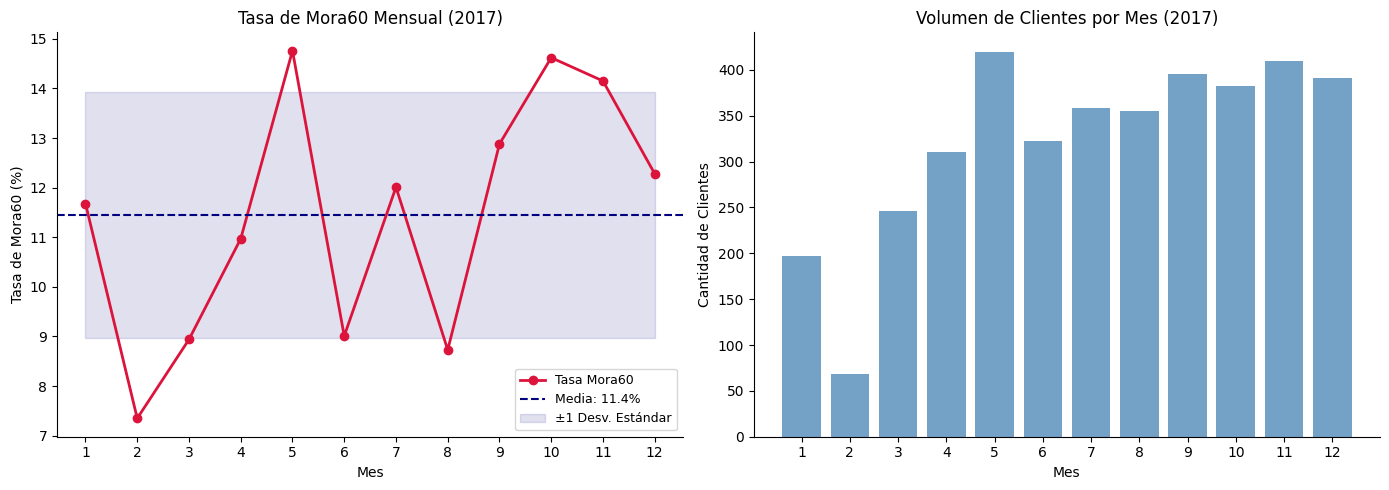


--- Resultados del Particionamiento ---
Train (2017 cronológico 80%) : 3,084 registros
Val   (2017 cronológico 20%) : 772 registros
Test  (2018 OOT completo)    : 459 registros

--- Tasa de Mora60 por Conjunto ---
Train  : 11.67%
Val    : 13.21%
Test   : 9.15%


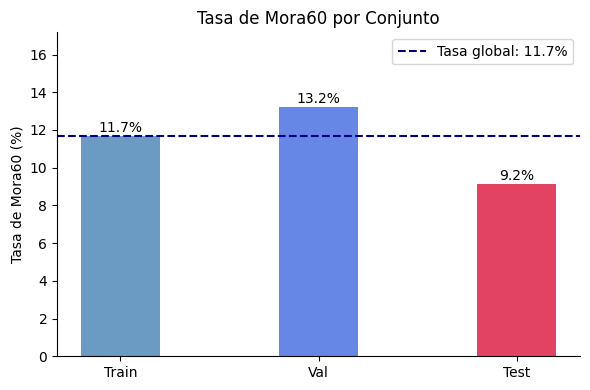

In [2]:
# ==============================================================================
# BLOQUE 2: ANÁLISIS DE ESTABILIDAD TEMPORAL Y PARTICIONAMIENTO
# ==============================================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------------------
# 2.1 Análisis de estabilidad mensual de la variable objetivo
# ------------------------------------------------------------------------------
# Antes de definir la estrategia de particionamiento, se evalúa la
# estacionalidad de la tasa de Mora60 en el año con cobertura completa (2017).
# Estabilidad temporal = particionamiento cronológico simple es viable.
# Inestabilidad fuerte = requeriría estratificación temporal más cuidadosa.
df_2017 = df[df['FFECHA'].dt.year == 2017].copy()
df_2017['Mes'] = df_2017['FFECHA'].dt.month

estabilidad_mora = df_2017.groupby('Mes')['Mora60'].agg(['count', 'mean'])
estabilidad_mora['mean'] = (estabilidad_mora['mean'] * 100).round(2)
estabilidad_mora.rename(columns={'count': 'Volumen_Clientes',
                                  'mean' : 'Tasa_Mora_Mensual_%'}, inplace=True)

# Métricas de dispersión para fundamentar la decisión
tasa_media = estabilidad_mora['Tasa_Mora_Mensual_%'].mean()
coef_var   = (estabilidad_mora['Tasa_Mora_Mensual_%'].std() / tasa_media * 100).round(1)

print("--- Estabilidad Temporal de Mora60 (2017) ---")
print(estabilidad_mora.to_string())
print(f"\nTasa media mensual         : {tasa_media:.2f}%")
print(f"Coeficiente de variación   : {coef_var:.1f}%")

# Visualización: tasa mensual con banda de ±1 desviación estándar y volumen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meses = estabilidad_mora.index
tasas = estabilidad_mora['Tasa_Mora_Mensual_%']

axes[0].plot(meses, tasas, marker='o', color='crimson', linewidth=2,
             label='Tasa Mora60')
axes[0].axhline(tasa_media, color='navy', linestyle='--', linewidth=1.5,
                label=f'Media: {tasa_media:.1f}%')
axes[0].fill_between(meses, tasa_media - tasas.std(), tasa_media + tasas.std(),
                      alpha=0.12, color='navy', label='±1 Desv. Estándar')
axes[0].set_title('Tasa de Mora60 Mensual (2017)')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Tasa de Mora60 (%)')
axes[0].set_xticks(meses)
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

axes[1].bar(meses, estabilidad_mora['Volumen_Clientes'],
            color='steelblue', alpha=0.75)
axes[1].set_title('Volumen de Clientes por Mes (2017)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad de Clientes')
axes[1].set_xticks(meses)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# Decisión: dado el CV moderado y la ausencia de meses extremos, se procede
# con particionamiento cronológico estricto (shuffle=False).

# ------------------------------------------------------------------------------
# 2.2 Particionamiento cronológico Train / Val / Test
# ------------------------------------------------------------------------------
# Estrategia:
#   - Train + Val : 2017 dividido 80/20 en orden cronológico
#   - Test (OOT)  : 2018 completo, aislado desde el inicio
#
# El uso de shuffle=False garantiza que validación contenga datos posteriores
# al entrenamiento, simulando el escenario real de producción y evitando
# data leakage temporal (que el modelo "vea el futuro").

df_2018 = df[df['FFECHA'].dt.year == 2018].copy()

df_train, df_val = train_test_split(
    df_2017.drop(columns=['Mes']),
    test_size=0.2,
    shuffle=False
)

print("\n--- Resultados del Particionamiento ---")
print(f"Train (2017 cronológico 80%) : {df_train.shape[0]:,} registros")
print(f"Val   (2017 cronológico 20%) : {df_val.shape[0]:,} registros")
print(f"Test  (2018 OOT completo)    : {df_2018.shape[0]:,} registros")

# ------------------------------------------------------------------------------
# 2.3 Verificación de representatividad del split
# ------------------------------------------------------------------------------
# Se valida que la tasa de Mora60 sea consistente entre los tres conjuntos.
# Diferencias significativas indicarían sesgo sistemático introducido por
# el particionamiento, lo cual invalidaría la evaluación posterior.
tasas_split = {
    'Train': df_train['Mora60'].mean() * 100,
    'Val'  : df_val['Mora60'].mean()   * 100,
    'Test' : df_2018['Mora60'].mean()  * 100
}

print("\n--- Tasa de Mora60 por Conjunto ---")
for nombre, tasa in tasas_split.items():
    print(f"{nombre:<6} : {tasa:.2f}%")

plt.figure(figsize=(6, 4))
bars = plt.bar(tasas_split.keys(), tasas_split.values(),
               color=['steelblue', 'royalblue', 'crimson'],
               alpha=0.8, width=0.4)
plt.axhline(df['Mora60'].mean() * 100, color='navy', linestyle='--',
            linewidth=1.5, label=f'Tasa global: {df["Mora60"].mean()*100:.1f}%')
for bar, val in zip(bars, tasas_split.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=10)
plt.title('Tasa de Mora60 por Conjunto')
plt.ylabel('Tasa de Mora60 (%)')
plt.ylim(0, max(tasas_split.values()) * 1.3)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Conclusión del bloque 2

**Selección de la variable objetivo.** Se adopta `Mora60` en lugar de `Mora30`. Los marcos
normativos distinguen entre alerta temprana e incumplimiento materializado: Basilea II y las
guías EBA sitúan el default a partir de 60–90 días, y la Circular Básica Contable y Financiera
de la Superintendencia Financiera de Colombia (Capítulo II) clasifica el consumo con 1 a 2
meses de mora en categoría B —riesgo aceptable— mientras que más de dos meses configura
categoría C, umbral desde el cual el incumplimiento compromete el recaudo normal.

La evidencia del propio conjunto refuerza la decisión: menos de la mitad de los clientes que
entraron en `Mora30` persistieron hasta `Mora60`. Modelar `Mora30` produciría un modelo
entrenado sobre eventos transitorios, que rechazaría clientes que en la práctica sí cumplen.

**Particionamiento.** La tasa mensual de `Mora60` durante 2017 presenta un coeficiente de
variación de 21.7% sin meses atípicos, lo que descarta estacionalidad marcada y valida un
corte cronológico sin sesgo sistemático. Se aplica un esquema Out-of-Time estricto:
entrenamiento y validación sobre 2017, prueba sobre la totalidad de 2018. La separación
reproduce las condiciones de producción, donde la decisión se toma con información del pasado
para predecir el futuro.

--- Análisis de Variables Categóricas vs Riesgo ---


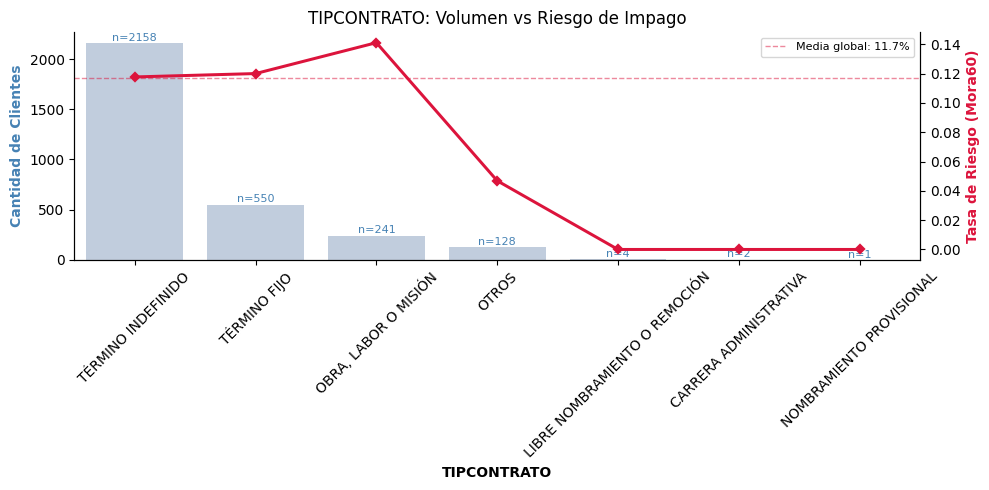

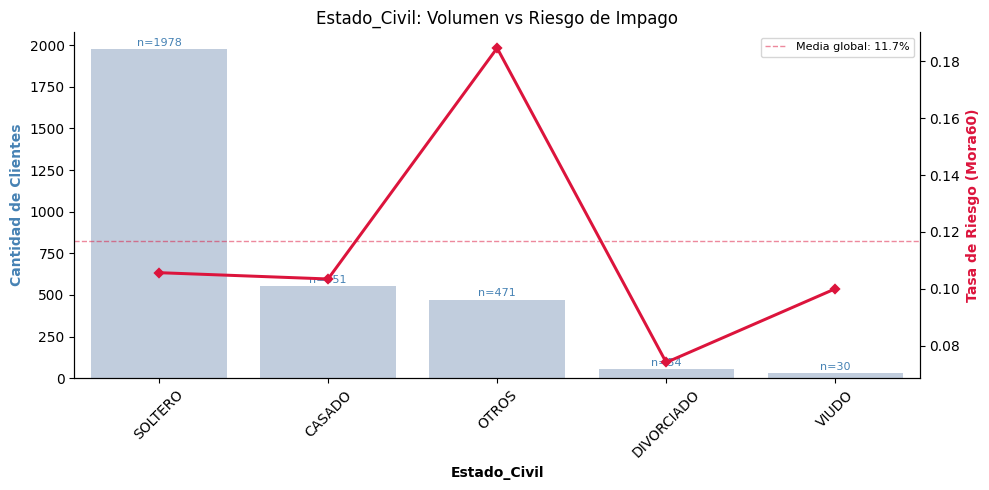

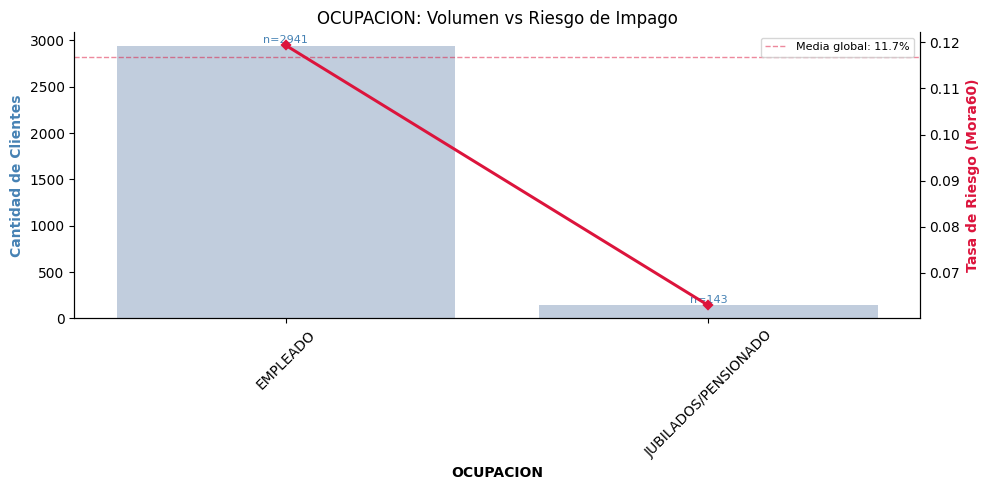

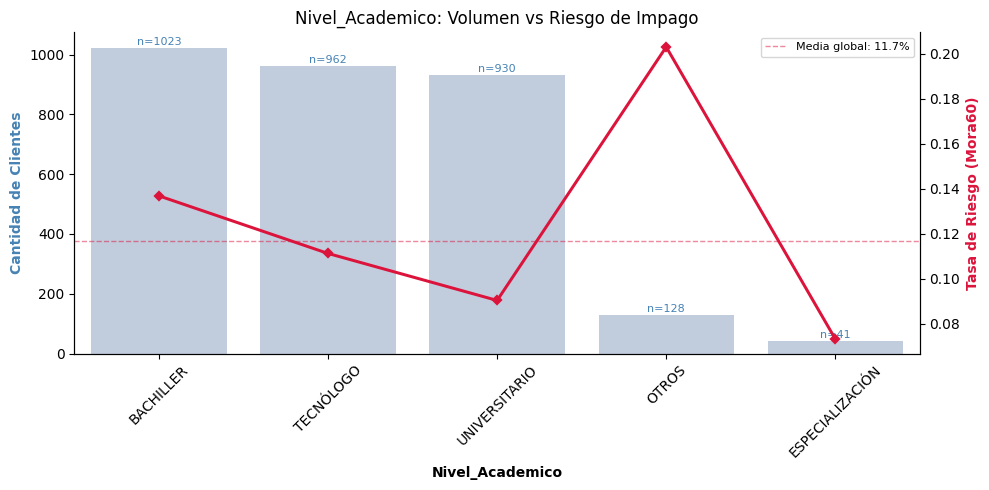

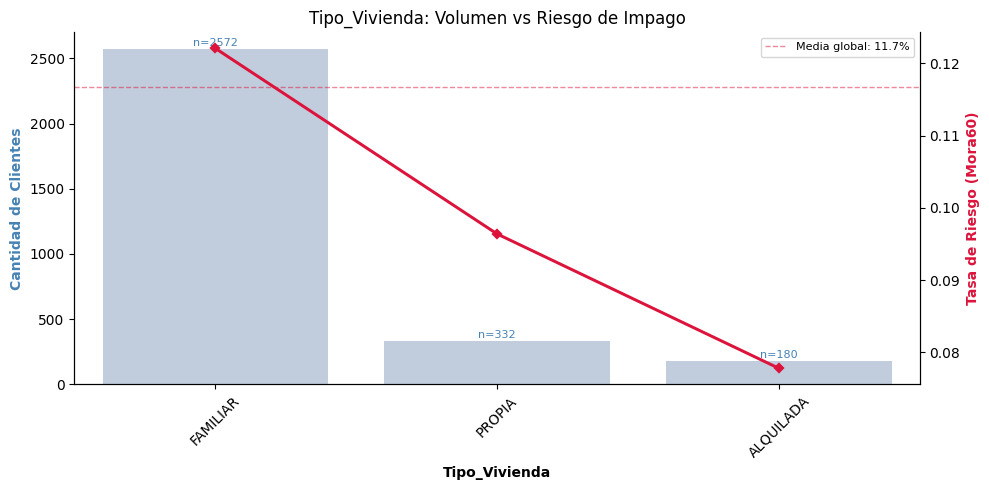


--- Auditoría de Sesgo Demográfico: Género ---


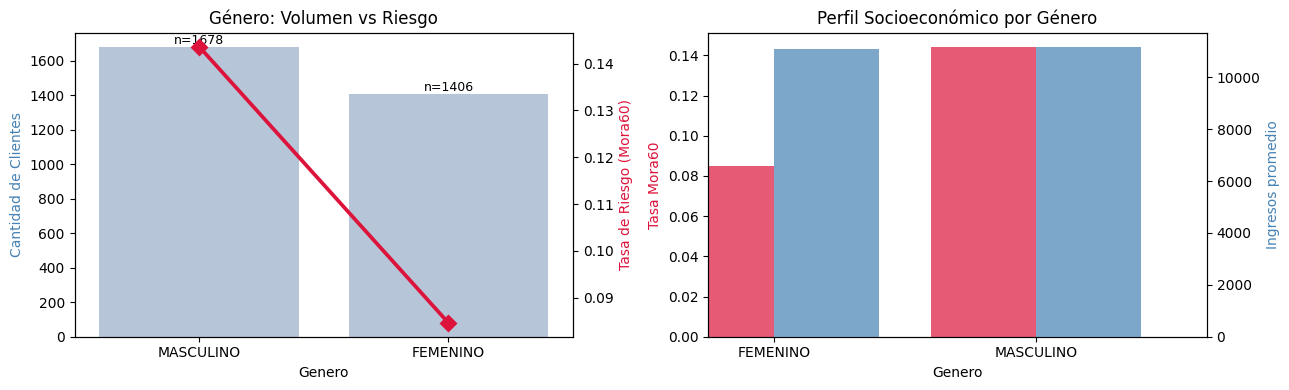

           Mora60_media  Ingresos_media  Edad_media
Genero                                             
FEMENINO          0.085       11074.432      33.130
MASCULINO         0.144       11154.280      33.853


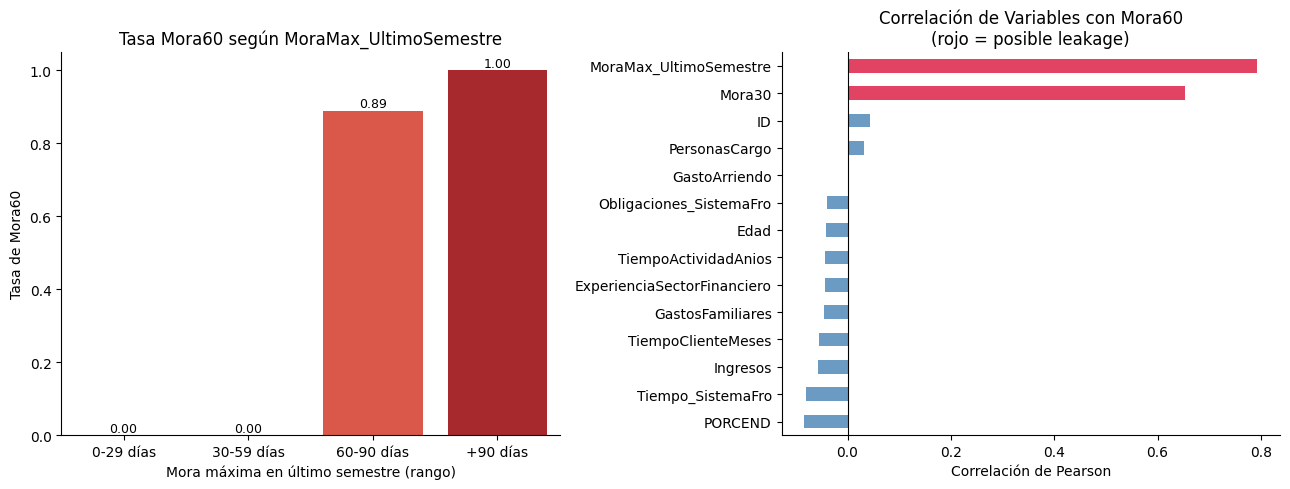

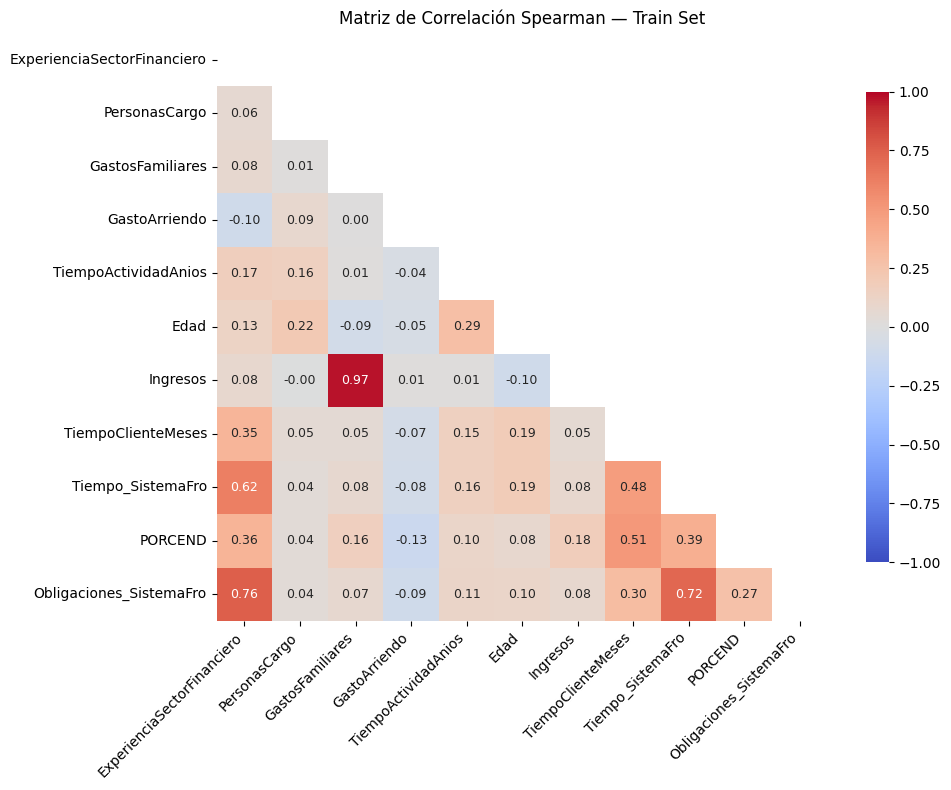


--- Pares con Colinealidad Alta (|rho| > 0.70) ---
                 Variable A              Variable B    Rho
           GastosFamiliares                Ingresos 0.9731
ExperienciaSectorFinanciero Obligaciones_SistemaFro 0.7563
          Tiempo_SistemaFro Obligaciones_SistemaFro 0.7220


In [3]:
# ==============================================================================
# BLOQUE 3: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==============================================================================
# El EDA se realiza exclusivamente sobre el conjunto de entrenamiento
# (df_train) para evitar contaminación con información del set de validación
# y test, lo cual sesgaría las decisiones de preprocesamiento posteriores.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 3.1 Función auxiliar: análisis bivariado de variables categóricas
# ------------------------------------------------------------------------------
# Genera un gráfico de doble eje:
#   - Eje izquierdo (barras) : volumen de clientes por categoría con N anotado
#   - Eje derecho (línea)    : tasa de mora media por categoría
#   - Línea de referencia    : tasa global del dataset
# Esta vista permite identificar simultáneamente la representatividad
# estadística de cada categoría y su poder discriminante.
def plot_volumen_vs_riesgo(df, columna_cat, target='Mora60'):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    orden = df[columna_cat].value_counts().index
    counts = df[columna_cat].value_counts()

    # Eje 1: volumen por categoría
    sns.countplot(data=df, x=columna_cat, order=orden,
                  ax=ax1, color='lightsteelblue', alpha=0.85)
    ax1.set_ylabel('Cantidad de Clientes', color='steelblue', fontweight='bold')
    ax1.set_xlabel(columna_cat, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)

    # Anotación de N por categoría (relevante para evaluar significancia)
    for i, cat in enumerate(orden):
        ax1.text(i, counts[cat] + counts.max() * 0.01,
                 f'n={counts[cat]}', ha='center', fontsize=8, color='steelblue')

    # Eje 2: tasa de riesgo por categoría
    ax2 = ax1.twinx()
    tasa = df.groupby(columna_cat)[target].mean().reindex(orden).reset_index()
    tasa.columns = [columna_cat, 'Tasa_Riesgo']

    sns.pointplot(data=tasa, x=columna_cat, y='Tasa_Riesgo',
                  ax=ax2, color='crimson', markers='D', scale=0.8)
    ax2.set_ylabel(f'Tasa de Riesgo ({target})',
                   color='crimson', fontweight='bold')

    # Línea de referencia: tasa global
    tasa_global = df[target].mean()
    ax2.axhline(tasa_global, color='crimson', linestyle='--',
                linewidth=1, alpha=0.5,
                label=f'Media global: {tasa_global*100:.1f}%')
    ax2.legend(fontsize=8, loc='upper right')

    plt.title(f'{columna_cat}: Volumen vs Riesgo de Impago')
    sns.despine(right=False)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 3.2 Análisis de variables categóricas principales
# ------------------------------------------------------------------------------
# Se analizan las variables categóricas relevantes para identificar:
#   - Categorías con baja representatividad (candidatas a agruparse)
#   - Variables con poder discriminante visible entre buenos y malos
print("--- Análisis de Variables Categóricas vs Riesgo ---")

cat_vars = ['TIPCONTRATO', 'Estado_Civil', 'OCUPACION',
            'Nivel_Academico', 'Tipo_Vivienda']

for var in cat_vars:
    plot_volumen_vs_riesgo(df_train, var, 'Mora60')

# ------------------------------------------------------------------------------
# 3.3 Auditoría de la variable Género
# ------------------------------------------------------------------------------
# Se analiza específicamente Género dado que es una variable demográfica
# protegida por normativa de equidad financiera. El objetivo es cuantificar
# si existe disparidad en la tasa de mora entre grupos antes de modelar.
# Esta auditoría fundamenta la construcción de dos versiones del modelo
# (V1 con Género / V2 sin Género) en bloques posteriores.
print("\n--- Auditoría de Sesgo Demográfico: Género ---")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico izquierdo: volumen vs riesgo por género
orden_g = df_train['Genero'].value_counts().index
counts_g = df_train['Genero'].value_counts()

sns.countplot(data=df_train, x='Genero', order=orden_g,
              ax=axes[0], color='lightsteelblue')
for i, cat in enumerate(orden_g):
    axes[0].text(i, counts_g[cat] + counts_g.max() * 0.01,
                 f'n={counts_g[cat]}', ha='center', fontsize=9)
axes[0].set_ylabel('Cantidad de Clientes', color='steelblue')

ax0_twin = axes[0].twinx()
tasa_g = df_train.groupby('Genero')['Mora60'].mean().reindex(orden_g).reset_index()
tasa_g.columns = ['Genero', 'Tasa_Riesgo']
sns.pointplot(data=tasa_g, x='Genero', y='Tasa_Riesgo',
              ax=ax0_twin, color='crimson', markers='D')
ax0_twin.set_ylabel('Tasa de Riesgo (Mora60)', color='crimson')
axes[0].set_title('Género: Volumen vs Riesgo')

# Gráfico derecho: perfil socioeconómico por género
# Permite evaluar si las diferencias en tasa de mora podrían ser un proxy
# de variables de capacidad de pago (ingresos, edad).
genero_stats = df_train.groupby('Genero').agg(
    Mora60_media   = ('Mora60',   'mean'),
    Ingresos_media = ('Ingresos', 'mean'),
    Edad_media     = ('Edad',     'mean')
).round(3)

genero_stats[['Mora60_media']].plot(
    kind='bar', ax=axes[1], color='crimson', alpha=0.7, width=0.4,
    position=1, legend=False
)
ax1_twin = axes[1].twinx()
genero_stats[['Ingresos_media']].plot(
    kind='bar', ax=ax1_twin, color='steelblue', alpha=0.7, width=0.4,
    position=0, legend=False
)
axes[1].set_ylabel('Tasa Mora60', color='crimson')
ax1_twin.set_ylabel('Ingresos promedio', color='steelblue')
axes[1].set_title('Perfil Socioeconómico por Género')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(genero_stats.to_string())

# Decisión: se construirán dos versiones del modelo
#   - V1 (con Género)  : baseline para auditar sesgo algorítmico vía SHAP
#   - V2 (sin Género)  : versión ética alineada con normativa
# La evaluación cuantitativa del trade-off se realiza en el Bloque 7.

# ------------------------------------------------------------------------------
# 3.4 Análisis de fuga de datos (Target Leakage)
# ------------------------------------------------------------------------------
# Se evalúa la relación entre MoraMax_UltimoSemestre y Mora60.
# Una variable que predice el target con casi total certeza no constituye
# información legítima sino fuga de datos: representa el resultado, no
# una causa anticipable en el momento de la originación.
df_temp = df_train.copy()
df_temp['Rango_MoraMax'] = pd.cut(
    df_temp['MoraMax_UltimoSemestre'],
    bins=[-1, 29, 59, 90, 400],
    labels=['0-29 días', '30-59 días', '60-90 días', '+90 días']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico izquierdo: tasa de mora por rango de MoraMax pasada
sns.barplot(data=df_temp, x='Rango_MoraMax', y='Mora60',
            palette='Reds', errorbar=None, ax=axes[0])
axes[0].set_title('Tasa Mora60 según MoraMax_UltimoSemestre')
axes[0].set_xlabel('Mora máxima en último semestre (rango)')
axes[0].set_ylabel('Tasa de Mora60')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9)
sns.despine(ax=axes[0])

# Gráfico derecho: correlación de variables numéricas con Mora60
# Se resaltan en rojo las variables relacionadas con mora (potencial leakage)
num_cols_corr = df_train.select_dtypes(include=np.number).columns.tolist()
corr_mora60 = df_train[num_cols_corr].corr()['Mora60'].drop('Mora60').sort_values()

colors = ['crimson' if 'Mora' in c else 'steelblue' for c in corr_mora60.index]
corr_mora60.plot(kind='barh', ax=axes[1], color=colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación de Variables con Mora60\n(rojo = posible leakage)')
axes[1].set_xlabel('Correlación de Pearson')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# Decisión: MoraMax_UltimoSemestre se excluye del pipeline de modelado.

# ------------------------------------------------------------------------------
# 3.5 Análisis de colinealidad entre variables numéricas
# ------------------------------------------------------------------------------
# Se utiliza correlación de Spearman (no paramétrica, captura relaciones
# monótonas no necesariamente lineales) para detectar pares de variables
# redundantes. Variables fuertemente correlacionadas pueden generar
# inestabilidad en la importancia atribuida y degradar la generalización.
variables_a_excluir_eda = ['ID', 'Mora30', 'Mora60', 'MoraMax_UltimoSemestre']
num_cols_eda = (df_train
                .select_dtypes(include=[np.number])
                .columns
                .drop(variables_a_excluir_eda, errors='ignore'))

corr_spearman = df_train[num_cols_eda].corr(method='spearman')
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', cbar_kws={'shrink': .8},
            vmin=-1, vmax=1, center=0, annot_kws={'size': 9})
plt.title('Matriz de Correlación Spearman — Train Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Detección automática de pares con colinealidad alta (|rho| > 0.70)
# para documentar las variables candidatas a exclusión.
pares_colineales = []
for i in range(len(corr_spearman.columns)):
    for j in range(i+1, len(corr_spearman.columns)):
        rho = corr_spearman.iloc[i, j]
        if abs(rho) > 0.70:
            pares_colineales.append({
                'Variable A': corr_spearman.columns[i],
                'Variable B': corr_spearman.columns[j],
                'Rho'       : round(rho, 4)
            })

print("\n--- Pares con Colinealidad Alta (|rho| > 0.70) ---")
if pares_colineales:
    print(pd.DataFrame(pares_colineales)
          .sort_values('Rho', ascending=False)
          .to_string(index=False))
else:
    print("No se detectaron pares con colinealidad alta.")

# Decisión: GastosFamiliares se excluye del modelo por su alta correlación
# con Ingresos. Se conserva Ingresos por mayor interpretabilidad de negocio.

### Conclusión del bloque 3

**Fuga de datos identificada.** `MoraMax_UltimoSemestre` presenta una correlación cercana a
0.8 con el objetivo y una tasa de `Mora60` del 100% en clientes con mora previa superior a
90 días. La variable es, en la práctica, mora futura observada: en el momento de originación
de un producto nuevo esa información no está disponible de forma confiable. Conservarla
habría producido métricas infladas y un modelo que colapsa en producción. Se excluye.

Se excluye igualmente `Mora30` como predictor, por arrastrar la misma fuga en una ventana más corta, y `GastosFamiliares`, con correlación de 0.9731 frente a
`Ingresos`, por redundancia informativa.

Tras estas exclusiones ninguna variable individual supera una correlación de 0.10 con
`Mora60`. Esto anticipa un techo estructural de desempeño: la ganancia adicional vendrá de
enriquecer el conjunto de datos, no de refinar el algoritmo.

In [4]:
# ==============================================================================
# BLOQUE 4: INGENIERÍA DE CARACTERÍSTICAS Y PIPELINE
# ==============================================================================
# Se definen transformadores personalizados que aplican las decisiones de
# preprocesamiento identificadas en el EDA. El uso de un Pipeline garantiza
# reproducibilidad y evita data leakage al ajustar transformaciones únicamente
# sobre el set de entrenamiento.

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from category_encoders import TargetEncoder
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 4.1 Transformadores personalizados
# ------------------------------------------------------------------------------

class LimpiadorActividad(BaseEstimator, TransformerMixin):
    """
    Aplica capping dinámico a TiempoActividadAnios.
    Límite lógico: máximo = Edad - 15 años (edad mínima razonable de inicio
    laboral). Esto corrige errores de digitación y casos donde la experiencia
    registrada supera la edad biológica del cliente.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        limite = X_out['Edad'] - 15
        X_out['TiempoActividadAnios'] = np.where(
            X_out['TiempoActividadAnios'] > limite,
            limite,
            X_out['TiempoActividadAnios']
        )
        X_out['TiempoActividadAnios'] = np.clip(
            X_out['TiempoActividadAnios'], a_min=0, a_max=None
        )
        return X_out


class AgrupadorContratos(BaseEstimator, TransformerMixin):
    """
    Colapsa categorías minoritarias de TIPCONTRATO en 'OTROS'.
    Aprende durante fit() qué categorías superan el umbral de representación
    (≥ 2% del set de entrenamiento) y aplica esa misma regla en transform().
    Esto garantiza consistencia entre entrenamiento y producción.
    """
    def __init__(self, umbral_pct=0.02):
        self.umbral_pct = umbral_pct
        self.categorias_validas_ = None

    def fit(self, X, y=None):
        if 'TIPCONTRATO' in X.columns:
            freq = X['TIPCONTRATO'].value_counts(normalize=True)
            self.categorias_validas_ = freq[freq >= self.umbral_pct].index.tolist()
        return self

    def transform(self, X):
        X_out = X.copy()
        if 'TIPCONTRATO' in X_out.columns and self.categorias_validas_ is not None:
            X_out['TIPCONTRATO'] = X_out['TIPCONTRATO'].apply(
                lambda x: x if x in self.categorias_validas_ else 'OTROS'
            )
        return X_out


class AgrupadorOcupacion(BaseEstimator, TransformerMixin):
    """
    Colapsa categorías minoritarias de OCUPACION en 'OTROS'.
    Misma lógica que AgrupadorContratos: las categorías marginales generan
    ruido estadístico sin valor predictivo robusto en producción.
    """
    def __init__(self, umbral_pct=0.02):
        self.umbral_pct = umbral_pct
        self.categorias_validas_ = None

    def fit(self, X, y=None):
        if 'OCUPACION' in X.columns:
            freq = X['OCUPACION'].value_counts(normalize=True)
            self.categorias_validas_ = freq[freq >= self.umbral_pct].index.tolist()
        return self

    def transform(self, X):
        X_out = X.copy()
        if 'OCUPACION' in X_out.columns and self.categorias_validas_ is not None:
            X_out['OCUPACION'] = X_out['OCUPACION'].apply(
                lambda x: x if x in self.categorias_validas_ else 'OTROS'
            )
        return X_out


class CreadorRatiosFinancieros(BaseEstimator, TransformerMixin):
    """
    Genera variables sintéticas que capturan estrés financiero relacional.
    Estos ratios traducen valores absolutos en métricas proporcionales,
    más informativas para predecir capacidad de pago:

      - Ratio_CargaFija         : proporción del ingreso comprometida en arriendo
      - Ingreso_PerCapita       : ingreso disponible por persona en el hogar
      - Velocidad_Endeudamiento : ritmo de acumulación de deuda como cliente

    Se añade un epsilon pequeño al denominador para evitar divisiones por cero
    en clientes sin obligaciones o sin tiempo registrado en el sistema.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        eps = 1e-5

        X_out['Ratio_CargaFija'] = (
            X_out['GastoArriendo'] / (X_out['Ingresos'] + eps)
        )
        X_out['Ingreso_PerCapita'] = (
            X_out['Ingresos'] / (X_out['PersonasCargo'] + 1)
        )
        X_out['Velocidad_Endeudamiento'] = (
            X_out['Obligaciones_SistemaFro'] / (X_out['TiempoClienteMeses'] + 1)
        )
        return X_out

# ------------------------------------------------------------------------------
# 4.2 Identificación dinámica de columnas
# ------------------------------------------------------------------------------
# Se excluyen identificadores, variables temporales, target leakage
# (MoraMax_UltimoSemestre) y variables redundantes (GastosFamiliares).
variables_a_excluir = ['ID', 'Mora30', 'Mora60', 'FFECHA',
                        'MoraMax_UltimoSemestre', 'GastosFamiliares']

cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = (df_train
            .select_dtypes(include=[np.number])
            .columns
            .drop(variables_a_excluir, errors='ignore')
            .tolist())

ratios_cols = ['Ratio_CargaFija', 'Ingreso_PerCapita', 'Velocidad_Endeudamiento']

print("--- Columnas del Pipeline ---")
print(f"Numéricas ({len(num_cols)})    : {num_cols}")
print(f"Categóricas ({len(cat_cols)})  : {cat_cols}")
print(f"Ratios ({len(ratios_cols)})    : {ratios_cols}")

# ------------------------------------------------------------------------------
# 4.3 Configuración del transformador matemático
# ------------------------------------------------------------------------------
# RobustScaler para variables numéricas: usa mediana y rango intercuartílico
# en lugar de media y desviación estándar, lo que lo hace resistente a
# outliers (relevante dado que variables como Ingresos tienen colas largas).
#
# TargetEncoder para variables categóricas: codifica cada categoría con su
# tasa de mora media, suavizada hacia la media global. El smoothing=10
# previene overfitting en categorías con pocos clientes (su valor codificado
# se desplaza hacia la media global cuando la muestra es pequeña).
preprocesador_matematico = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols + ratios_cols),
        ('cat', TargetEncoder(min_samples_leaf=20, smoothing=10), cat_cols)
    ],
    remainder='drop'  # descarta automáticamente columnas no especificadas
)

# ------------------------------------------------------------------------------
# 4.4 Ensamblaje del pipeline
# ------------------------------------------------------------------------------
# Orden de los pasos:
#   1. Limpieza de outliers en TiempoActividadAnios
#   2. Agrupación de categorías minoritarias en TIPCONTRATO
#   3. Agrupación de categorías minoritarias en OCUPACION
#   4. Generación de ratios financieros (requiere variables originales)
#   5. Escalado y encoding final
pipeline_maestro = Pipeline(steps=[
    ('limpieza_actividad',  LimpiadorActividad()),
    ('agrupador_contratos', AgrupadorContratos()),
    ('agrupador_ocupacion', AgrupadorOcupacion()),
    ('ingenieria_ratios',   CreadorRatiosFinancieros()),
    ('matematicas',         preprocesador_matematico)
])

# ------------------------------------------------------------------------------
# 4.5 Aplicación del pipeline
# ------------------------------------------------------------------------------
# fit_transform únicamente sobre Train para evitar contaminación.
# transform sobre Val y Test (usan parámetros aprendidos en Train).
X_train_processed = pipeline_maestro.fit_transform(df_train, df_train['Mora60'])
X_val_processed   = pipeline_maestro.transform(df_val)
X_test_processed  = pipeline_maestro.transform(df_2018)

# Extracción del target
y_train = df_train['Mora60'].values
y_val   = df_val['Mora60'].values
y_test  = df_2018['Mora60'].values

print("\n--- Pipeline Aplicado ---")
print(f"Train procesado : {X_train_processed.shape}")
print(f"Val procesado   : {X_val_processed.shape}")
print(f"Test procesado  : {X_test_processed.shape}")

# Verificación de integridad post-pipeline
print("\n--- Verificación Post-Pipeline ---")
for nombre, X in [('Train', X_train_processed),
                   ('Val',   X_val_processed),
                   ('Test',  X_test_processed)]:
    nans = np.isnan(X).sum()
    infs = np.isinf(X).sum()
    status = '✓ OK' if nans == 0 and infs == 0 else '✗ REVISAR'
    print(f"{nombre:<6} — NaNs: {nans} | Infs: {infs} | {status}")

--- Columnas del Pipeline ---
Numéricas (10)    : ['ExperienciaSectorFinanciero', 'PersonasCargo', 'GastoArriendo', 'TiempoActividadAnios', 'Edad', 'Ingresos', 'TiempoClienteMeses', 'Tiempo_SistemaFro', 'PORCEND', 'Obligaciones_SistemaFro']
Categóricas (6)  : ['OCUPACION', 'TIPCONTRATO', 'Estado_Civil', 'Genero', 'Nivel_Academico', 'Tipo_Vivienda']
Ratios (3)    : ['Ratio_CargaFija', 'Ingreso_PerCapita', 'Velocidad_Endeudamiento']

--- Pipeline Aplicado ---
Train procesado : (3084, 19)
Val procesado   : (772, 19)
Test procesado  : (459, 19)

--- Verificación Post-Pipeline ---
Train  — NaNs: 0 | Infs: 0 | ✓ OK
Val    — NaNs: 0 | Infs: 0 | ✓ OK
Test   — NaNs: 0 | Infs: 0 | ✓ OK


### Conclusión del bloque 4

Las transformaciones quedan encapsuladas en un `Pipeline` de scikit-learn, de modo que el
ajuste ocurre exclusivamente sobre entrenamiento y se propaga a validación y prueba sin
contaminación. Los transformadores personalizados corrigen anomalías de captura y colapsan
categorías minoritarias.

Se construyen tres ratios financieros cuyo aporte es traducir valores absolutos en medidas de
estrés proporcional: dos clientes con el mismo ingreso no representan el mismo riesgo si su
carga fija difiere.

--- Diagnóstico de Desbalance ---
Buenos (0) en Train : 2,724 (88.3%)
Malos  (1) en Train : 360 (11.7%)
Ratio desbalance    : 7.6:1

--- Iniciando Optimización Bayesiana (30 trials) ---

Mejor AUC alcanzado en Validación : 0.6475
GINI equivalente                  : 29.49%

Mejores hiperparámetros:
  learning_rate             : 0.035256922355015215
  num_leaves                : 86
  max_depth                 : 9
  min_child_samples         : 67
  feature_fraction          : 0.6917697397561665
  bagging_fraction          : 0.6982543031853186
  bagging_freq              : 3
  lambda_l1                 : 0.0001057270508134851
  lambda_l2                 : 0.0024436865441380584


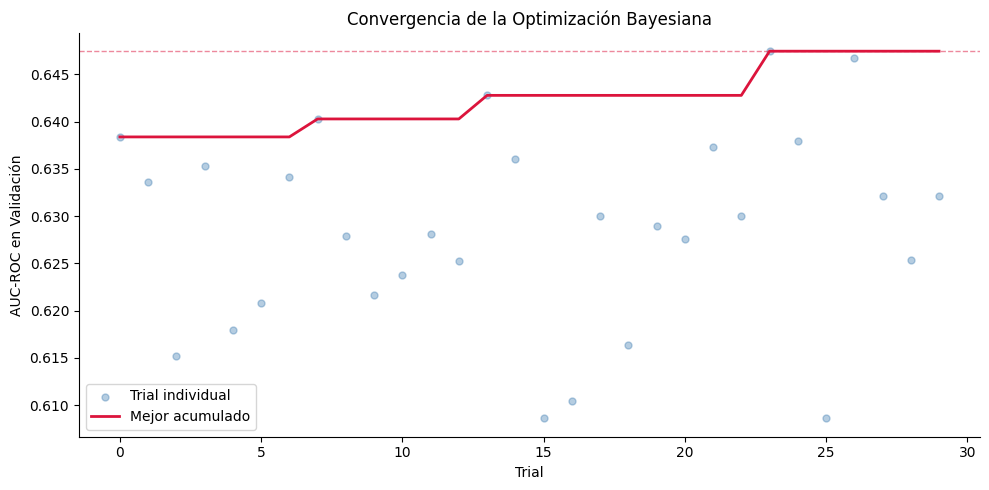


--- Modelo V1 Entrenado ---
Iteraciones óptimas : 1
AUC Train           : 0.6640 | GINI: 32.80%
AUC Validación      : 0.6475   | GINI: 29.49%
Brecha Train-Val    : 1.65 pts


In [5]:
# ==============================================================================
# BLOQUE 5: OPTIMIZACIÓN DE HIPERPARÁMETROS Y ENTRENAMIENTO (V1)
# ==============================================================================
# Se utiliza Optuna (optimización bayesiana) para encontrar la combinación
# de hiperparámetros que maximiza el AUC-ROC sobre el set de validación.
# El algoritmo elegido es LightGBM por su robustez ante variables categóricas
# encoded, su manejo nativo de desbalance de clases y su eficiencia
# computacional con datasets de tamaño moderado.

import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# 5.1 Diagnóstico del desbalance de clases
# ------------------------------------------------------------------------------
# Se cuantifica el ratio de desbalance para fundamentar la estrategia
# de manejo elegida (is_unbalance=True en LightGBM).
tasa_mora_train  = y_train.mean()
ratio_desbalance = (1 - tasa_mora_train) / tasa_mora_train

print("--- Diagnóstico de Desbalance ---")
print(f"Buenos (0) en Train : {(y_train == 0).sum():,} ({(1-tasa_mora_train)*100:.1f}%)")
print(f"Malos  (1) en Train : {(y_train == 1).sum():,} ({tasa_mora_train*100:.1f}%)")
print(f"Ratio desbalance    : {ratio_desbalance:.1f}:1")

# Decisión: is_unbalance=True ajusta internamente los pesos de clase de
# forma proporcional al ratio detectado, sin requerir over/under-sampling
# explícito (que podría introducir registros sintéticos sesgados).

# ------------------------------------------------------------------------------
# 5.2 Función objetivo para la optimización bayesiana
# ------------------------------------------------------------------------------
# Define el espacio de búsqueda y evalúa cada combinación con early stopping
# para evitar sobreajuste durante el proceso de búsqueda.
#
# Notas sobre el espacio de búsqueda:
#   - num_leaves y max_depth controlan la complejidad del árbol
#   - min_child_samples ≥ 20 evita hojas con poblaciones no representativas
#     (relevante dado el tamaño moderado del dataset, ~3,000 obs.)
#   - feature_fraction y bagging_fraction añaden regularización por subsampling
#   - lambda_l1 y lambda_l2 son regularizadores explícitos sobre los pesos
def objective(trial):
    param = {
        'objective'    : 'binary',
        'metric'       : 'auc',
        'boosting_type': 'gbdt',
        'is_unbalance' : True,
        'verbose'      : -1,
        'random_state' : 42,
        # Estructura del árbol
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 10, 100),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        # Regularización por subsampling
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq'     : trial.suggest_int('bagging_freq', 1, 7),
        # Regularización L1 y L2
        'lambda_l1'        : trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2'        : trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    dtrain = lgb.Dataset(X_train_processed, label=y_train)
    dval   = lgb.Dataset(X_val_processed,   label=y_val, reference=dtrain)

    gbm = lgb.train(
        param,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dtrain, dval],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=20, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )

    preds = gbm.predict(X_val_processed, num_iteration=gbm.best_iteration)
    return roc_auc_score(y_val, preds)

# ------------------------------------------------------------------------------
# 5.3 Ejecución de la optimización
# ------------------------------------------------------------------------------
# Se usa TPESampler (Tree-structured Parzen Estimator), que aprende de
# trials anteriores para enfocar la búsqueda en regiones prometedoras.
# La semilla fija (seed=42) garantiza reproducibilidad estricta.
print("\n--- Iniciando Optimización Bayesiana (30 trials) ---")
sampler = optuna.samplers.TPESampler(seed=42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30)

print(f"\nMejor AUC alcanzado en Validación : {study.best_value:.4f}")
print(f"GINI equivalente                  : {(2*study.best_value-1)*100:.2f}%")
print(f"\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:<25} : {v}")

# ------------------------------------------------------------------------------
# 5.4 Visualización de la convergencia
# ------------------------------------------------------------------------------
# Permite verificar si la optimización convergió o si aún había potencial
# de mejora con más trials. La curva acumulada estable indica convergencia.
trials_df = study.trials_dataframe()
trials_df['best_so_far'] = trials_df['value'].cummax()

plt.figure(figsize=(10, 5))
plt.scatter(trials_df.index, trials_df['value'],
            color='steelblue', alpha=0.4, s=25, label='Trial individual')
plt.plot(trials_df.index, trials_df['best_so_far'],
         color='crimson', linewidth=2, label='Mejor acumulado')
plt.axhline(study.best_value, color='crimson', linestyle='--',
            alpha=0.5, linewidth=1)
plt.title('Convergencia de la Optimización Bayesiana')
plt.xlabel('Trial')
plt.ylabel('AUC-ROC en Validación')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5.5 Entrenamiento del Modelo V1 definitivo
# ------------------------------------------------------------------------------
# Se entrena el modelo final con los hiperparámetros óptimos encontrados.
# Este modelo V1 incluye todas las variables disponibles (incluido Género)
# y servirá como baseline para la auditoría de sesgo en el Bloque 7.
best_params = study.best_params.copy()
best_params.update({
    'objective'    : 'binary',
    'metric'       : 'auc',
    'boosting_type': 'gbdt',
    'is_unbalance' : True,
    'verbose'      : -1,
    'random_state' : 42
})

dtrain_final = lgb.Dataset(X_train_processed, label=y_train)
dval_final   = lgb.Dataset(X_val_processed,   label=y_val, reference=dtrain_final)

modelo_v1 = lgb.train(
    best_params,
    dtrain_final,
    num_boost_round=1000,
    valid_sets=[dtrain_final, dval_final],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# Diagnóstico de sobreajuste: brecha entre AUC en Train y AUC en Validación
auc_train_v1 = roc_auc_score(y_train, modelo_v1.predict(X_train_processed))
auc_val_v1   = roc_auc_score(y_val,   modelo_v1.predict(X_val_processed))
brecha       = auc_train_v1 - auc_val_v1

print(f"\n--- Modelo V1 Entrenado ---")
print(f"Iteraciones óptimas : {modelo_v1.best_iteration}")
print(f"AUC Train           : {auc_train_v1:.4f} | GINI: {(2*auc_train_v1-1)*100:.2f}%")
print(f"AUC Validación      : {auc_val_v1:.4f}   | GINI: {(2*auc_val_v1-1)*100:.2f}%")
print(f"Brecha Train-Val    : {brecha*100:.2f} pts")

### Conclusión del bloque 5

Se selecciona LightGBM por su robustez ante variables categóricas codificadas, el manejo
nativo del desbalance mediante `scale_pos_weight` —evitando artefactos de remuestreo— y su
eficiencia sobre conjuntos de tamaño moderado.

La optimización de hiperparámetros se realiza con búsqueda bayesiana (Optuna) maximizando
AUC-ROC sobre validación, alcanzando 0.6475.

**Limitación del espacio de búsqueda.** La combinación seleccionada (`num_leaves=86`,
`max_depth=9`) produce árboles grandes para un conjunto de 3.084 registros: el AUC de
validación deja de mejorar tras la primera iteración y el early stopping fija
`best_iteration=1`. En la práctica V1 opera como un único árbol y el boosting no aporta.
La consecuencia se hace visible en el bloque 10: las probabilidades de V1 se concentran en
una banda estrecha, lo que vuelve su política de corte muy sensible al umbral. Acotar
`num_leaves` y `max_depth` en la búsqueda sería la corrección natural.

--- Rendimiento sobre Test OOT (Cohorte 2018) ---
ROC-AUC : 0.6267
GINI    : 25.34%


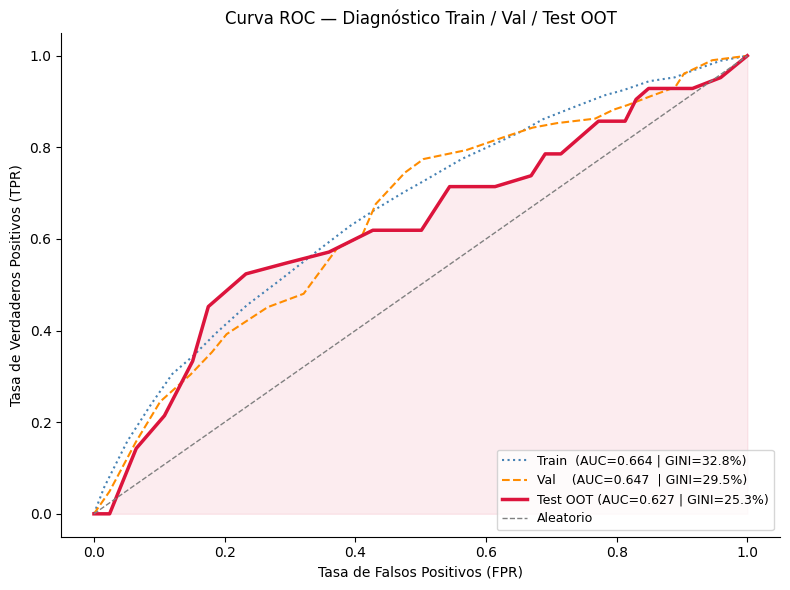


--- Definición del Punto de Corte ---
(calculado sobre Validación para evitar leakage metodológico)

Criterio 1 — Máximo F1-Score : umbral = 0.1306 | F1 = 0.3058
Criterio 2 — Máximo Youden J : umbral = 0.1296 | TPR=0.775, FPR=0.504


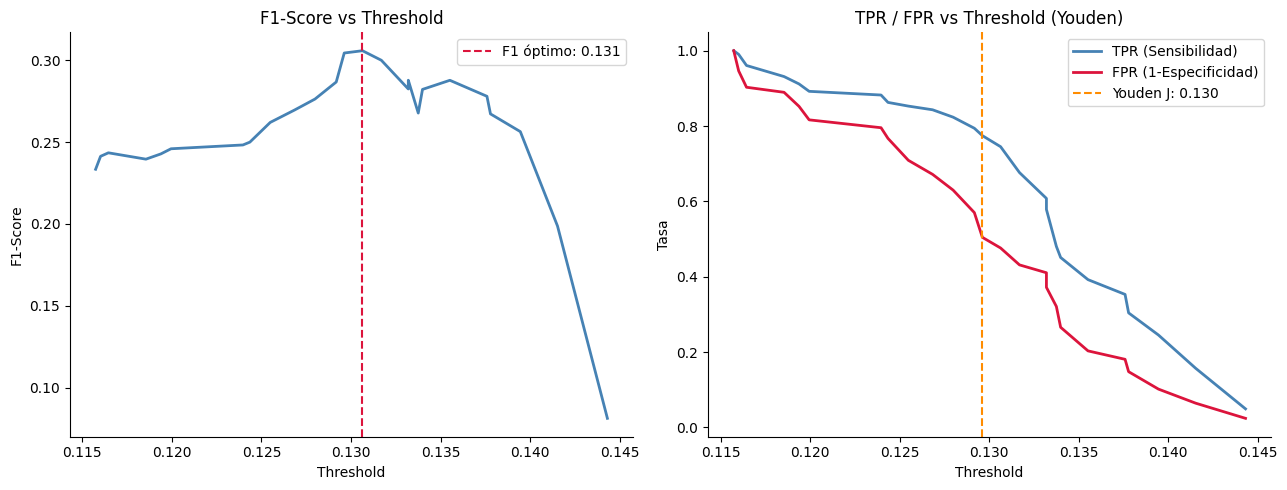


--- Comparativa de Umbrales sobre Test OOT ---
             Criterio  Umbral  Precisión  Recall  F1-Score  Tasa Aprobación %
F1-Score (equilibrio)  0.1306     0.1167  0.7143    0.2007               44.0
    Youden J (riesgo)  0.1296     0.1145  0.7143    0.1974               42.9


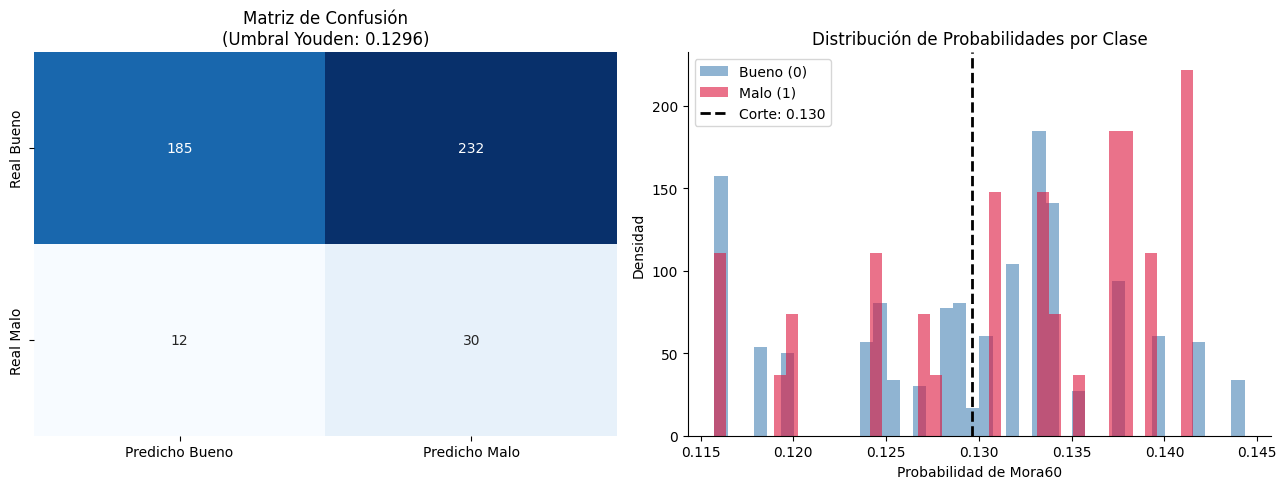

In [6]:
# ==============================================================================
# BLOQUE 6: EVALUACIÓN OUT-OF-TIME Y PUNTO DE CORTE
# ==============================================================================
# Se evalúa la capacidad de generalización del Modelo V1 sobre la cohorte
# de 2018 (datos nunca usados en entrenamiento ni optimización) y se define
# el punto de corte óptimo para la toma de decisiones de aprobación.

from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                              precision_recall_curve, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 6.1 Predicciones de probabilidad
# ------------------------------------------------------------------------------
# El modelo genera la probabilidad continua de impago (Mora60) para cada
# cliente. Estas probabilidades se transformarán en decisiones binarias
# mediante el punto de corte definido más adelante.
preds_prob_train = modelo_v1.predict(X_train_processed)
preds_prob_val   = modelo_v1.predict(X_val_processed)
preds_prob_test  = modelo_v1.predict(X_test_processed)

# ------------------------------------------------------------------------------
# 6.2 Métricas de discriminación sobre Test OOT
# ------------------------------------------------------------------------------
# AUC-ROC mide la capacidad de ordenar correctamente clientes buenos vs
# malos, independientemente del umbral. GINI = 2*AUC - 1 es la métrica
# estándar en la industria de scoring crediticio (rango: 0% aleatorio,
# 100% perfecto).
auc_test  = roc_auc_score(y_test, preds_prob_test)
gini_test = (2 * auc_test) - 1

print("--- Rendimiento sobre Test OOT (Cohorte 2018) ---")
print(f"ROC-AUC : {auc_test:.4f}")
print(f"GINI    : {gini_test*100:.2f}%")

# ------------------------------------------------------------------------------
# 6.3 Curva ROC: diagnóstico de generalización
# ------------------------------------------------------------------------------
# Se grafican las curvas de Train, Validación y Test en un solo gráfico
# para visualizar la consistencia del rendimiento entre conjuntos.
# Brechas grandes Train-Test indicarían sobreajuste.
fpr_train, tpr_train, _ = roc_curve(y_train, preds_prob_train)
fpr_val,   tpr_val,   _ = roc_curve(y_val,   preds_prob_val)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  preds_prob_test)

auc_train = roc_auc_score(y_train, preds_prob_train)
auc_val   = roc_auc_score(y_val,   preds_prob_val)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='steelblue', lw=1.5, linestyle=':',
         label=f'Train  (AUC={auc_train:.3f} | GINI={(2*auc_train-1)*100:.1f}%)')
plt.plot(fpr_val,   tpr_val,   color='darkorange', lw=1.5, linestyle='--',
         label=f'Val    (AUC={auc_val:.3f}  | GINI={(2*auc_val-1)*100:.1f}%)')
plt.plot(fpr_test,  tpr_test,  color='crimson',    lw=2.5,
         label=f'Test OOT (AUC={auc_test:.3f} | GINI={gini_test*100:.1f}%)')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Aleatorio')
plt.fill_between(fpr_test, tpr_test, alpha=0.08, color='crimson')
plt.title('Curva ROC — Diagnóstico Train / Val / Test OOT')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6.4 Definición del punto de corte
# ------------------------------------------------------------------------------
# El umbral se calcula sobre el set de Validación (no sobre Test) para
# evitar leakage metodológico al evaluar el rendimiento final.
# Se evalúan dos criterios complementarios:
#   - F1-Score : balancea precisión y recall, útil con clases desbalanceadas
#   - Youden J : maximiza (Sensibilidad + Especificidad - 1), estándar
#                en scoring crediticio porque no privilegia ninguna clase
print("\n--- Definición del Punto de Corte ---")
print("(calculado sobre Validación para evitar leakage metodológico)")

precision_v, recall_v, thresholds_pr = precision_recall_curve(y_val, preds_prob_val)
fpr_v, tpr_v, thresholds_roc         = roc_curve(y_val, preds_prob_val)

# Alineamiento robusto de arrays (sklearn devuelve tamaños distintos según
# la versión; se toma la longitud mínima común).
n_pr = len(thresholds_pr)
precision_v_trim = precision_v[:n_pr]
recall_v_trim    = recall_v[:n_pr]

n_roc = min(len(thresholds_roc), len(tpr_v), len(fpr_v))
thresholds_roc_a = thresholds_roc[:n_roc]
tpr_v_a          = tpr_v[:n_roc]
fpr_v_a          = fpr_v[:n_roc]

# Criterio 1: maximizar F1-Score
f1_scores = np.divide(
    2 * precision_v_trim * recall_v_trim,
    precision_v_trim + recall_v_trim,
    out=np.zeros_like(precision_v_trim),
    where=(precision_v_trim + recall_v_trim) > 0
)
idx_f1    = np.argmax(f1_scores)
umbral_f1 = thresholds_pr[idx_f1]

# Criterio 2: maximizar Youden J (TPR - FPR)
youden        = tpr_v_a - fpr_v_a
idx_youden    = np.argmax(youden)
umbral_youden = thresholds_roc_a[idx_youden]

print(f"\nCriterio 1 — Máximo F1-Score : umbral = {umbral_f1:.4f} "
      f"| F1 = {f1_scores[idx_f1]:.4f}")
print(f"Criterio 2 — Máximo Youden J : umbral = {umbral_youden:.4f} "
      f"| TPR={tpr_v_a[idx_youden]:.3f}, FPR={fpr_v_a[idx_youden]:.3f}")

# ------------------------------------------------------------------------------
# 6.5 Visualización de los criterios de corte
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: F1 vs Threshold
axes[0].plot(thresholds_pr, f1_scores, color='steelblue', lw=2)
axes[0].axvline(umbral_f1, color='crimson', linestyle='--', lw=1.5,
                label=f'F1 óptimo: {umbral_f1:.3f}')
axes[0].set_title('F1-Score vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1-Score')
axes[0].legend()
sns.despine(ax=axes[0])

# Gráfico 2: TPR y FPR vs Threshold (criterio Youden)
axes[1].plot(thresholds_roc_a, tpr_v_a, color='steelblue', lw=2,
             label='TPR (Sensibilidad)')
axes[1].plot(thresholds_roc_a, fpr_v_a, color='crimson', lw=2,
             label='FPR (1-Especificidad)')
axes[1].axvline(umbral_youden, color='darkorange', linestyle='--', lw=1.5,
                label=f'Youden J: {umbral_youden:.3f}')
axes[1].set_title('TPR / FPR vs Threshold (Youden)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Tasa')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6.6 Comparación de umbrales sobre Test OOT
# ------------------------------------------------------------------------------
# Se aplican ambos umbrales sobre el set de prueba para evaluar las
# implicaciones operativas de cada criterio (tasa de aprobación, errores).
umbrales = {
    'F1-Score (equilibrio)' : umbral_f1,
    'Youden J (riesgo)'     : umbral_youden
}

resultados = []
for nombre, umbral in umbrales.items():
    preds_bin = (preds_prob_test >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_bin).ravel()
    precision_u = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_u    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_u        = f1_score(y_test, preds_bin)
    aprobacion  = (preds_bin == 0).mean() * 100

    resultados.append({
        'Criterio'          : nombre,
        'Umbral'            : round(umbral, 4),
        'Precisión'         : round(precision_u, 4),
        'Recall'            : round(recall_u, 4),
        'F1-Score'          : round(f1_u, 4),
        'Tasa Aprobación %' : round(aprobacion, 1),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

df_resultados = pd.DataFrame(resultados)
print("\n--- Comparativa de Umbrales sobre Test OOT ---")
print(df_resultados[['Criterio', 'Umbral', 'Precisión',
                      'Recall', 'F1-Score', 'Tasa Aprobación %']].to_string(index=False))

# ------------------------------------------------------------------------------
# 6.7 Matriz de confusión y distribución de probabilidades
# ------------------------------------------------------------------------------
# Se visualiza el comportamiento del umbral seleccionado (Youden J por ser
# estándar en scoring crediticio) sobre el set de prueba.
umbral_final    = umbral_youden
preds_bin_final = (preds_prob_test >= umbral_final).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, preds_bin_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho Bueno', 'Predicho Malo'],
            yticklabels=['Real Bueno', 'Real Malo'],
            ax=axes[0], cbar=False)
axes[0].set_title(f'Matriz de Confusión\n(Umbral Youden: {umbral_final:.4f})')

# Distribución de probabilidades por clase real
# Permite visualizar la separación entre buenos y malos en el espacio
# de predicciones del modelo.
axes[1].hist(preds_prob_test[y_test == 0], bins=40, alpha=0.6,
             color='steelblue', label='Bueno (0)', density=True)
axes[1].hist(preds_prob_test[y_test == 1], bins=40, alpha=0.6,
             color='crimson',   label='Malo (1)',  density=True)
axes[1].axvline(umbral_final, color='black', linestyle='--', lw=2,
                label=f'Corte: {umbral_final:.3f}')
axes[1].set_title('Distribución de Probabilidades por Clase')
axes[1].set_xlabel('Probabilidad de Mora60')
axes[1].set_ylabel('Densidad')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### Conclusión del bloque 6

| Métrica | Train | Validación | Prueba OOT |
|---|---|---|---|
| AUC-ROC | 0.6640 | 0.6475 | 0.6267 |
| GINI | 32.80% | 29.49% | 25.34% |

La degradación es progresiva y moderada, sin la brecha abrupta que indicaría sobreajuste. El
GINI de 25.34% sobre datos fuera de tiempo se ubica en el rango reconocido como aceptable para
originación en segmentos de alto riesgo, donde la señal es inherentemente más limitada que en
segmentos estándar.

**Punto de corte.** El umbral se calcula sobre validación y no sobre la prueba OOT, para no
contaminar la evaluación final. Se recomienda el criterio de Youden J (0.1296), estándar en
scoring crediticio por maximizar la suma de sensibilidad y especificidad sin privilegiar
ninguna clase. Aplicado sobre OOT produce una tasa de aprobación de 42.9% y un recall de
71.4%: detecta 7 de cada 10 morosos reales.

Este umbral pertenece a la escala de puntajes de V1 y **no es transferible a otro modelo**.
El bloque 10 recalcula el corte correspondiente a V2.

--- Auditoría SHAP del Modelo V1 ---


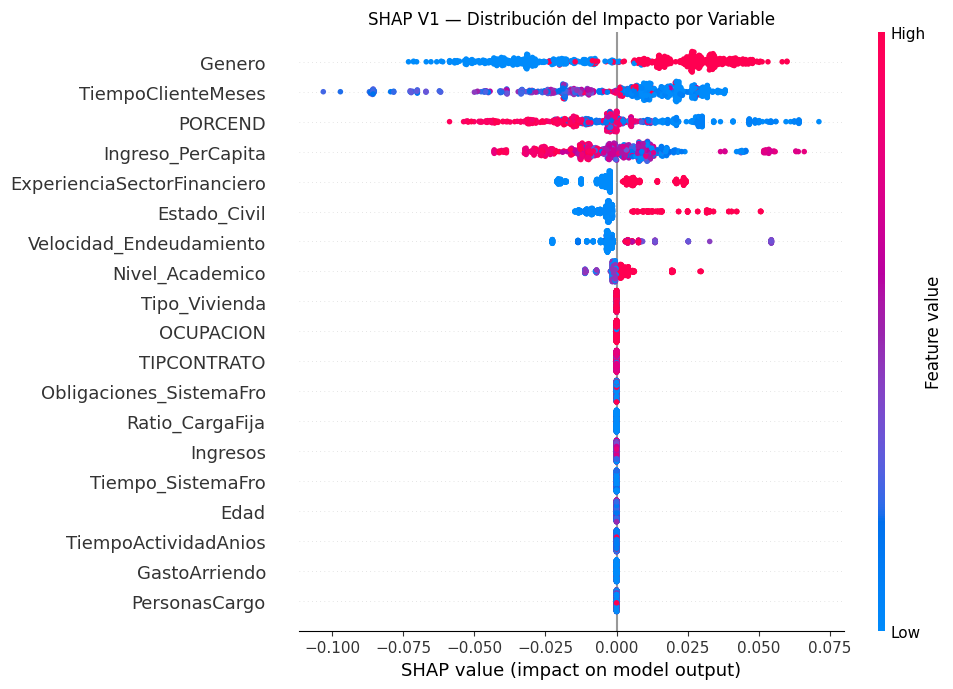

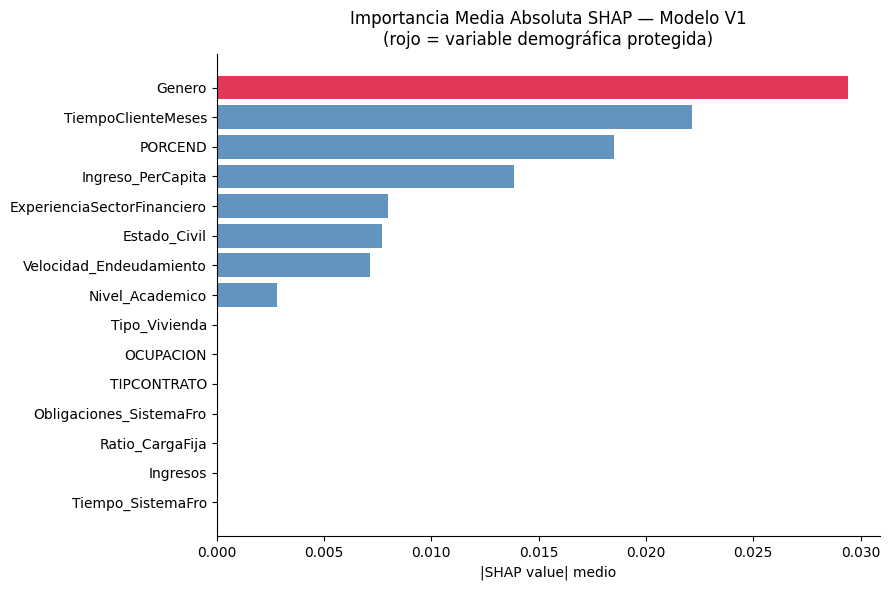


Peso de Género en las decisiones del Modelo V1:
  SHAP medio absoluto      : 0.0294
  % del peso total visible : 26.86%

--- Construcción del Modelo V2 (sin Género) ---
Train V2 : (3084, 18)
Val V2   : (772, 18)
Test V2  : (459, 18)

Modelo V2 entrenado.
Iteraciones óptimas : 41

--- Auditoría SHAP del Modelo V2 ---


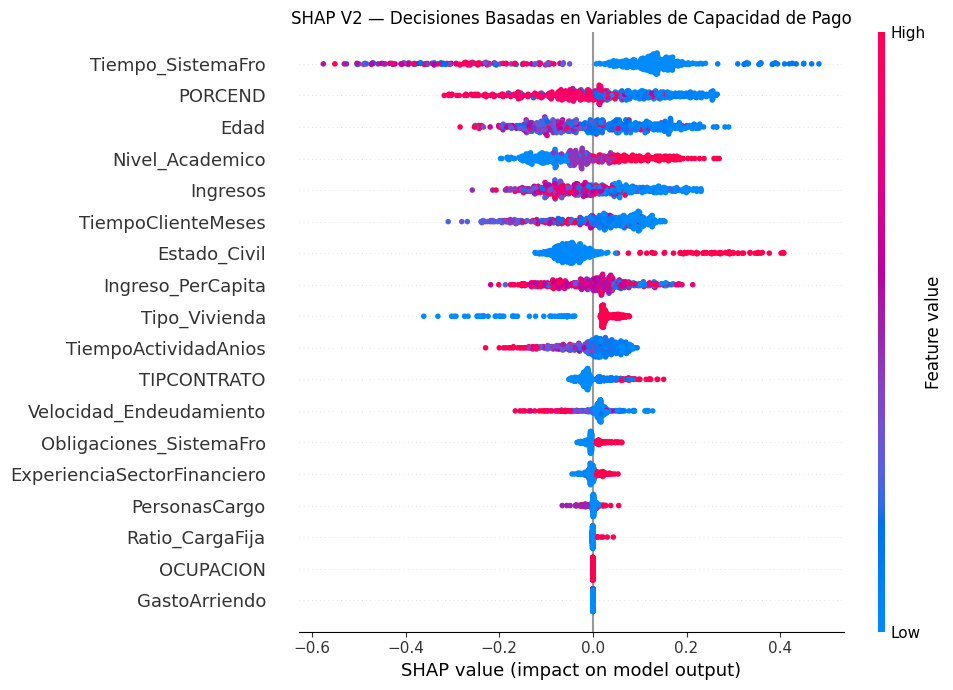


  RESUMEN COMPARATIVO: MODELO V1 vs MODELO V2
                 Métrica Modelo V1 (Con Género) Modelo V2 (Sin Género) Diferencia
      ROC-AUC (Test OOT)                 0.6267                 0.6169    +0.0098
         GINI (Test OOT)                 25.34%                 23.38%  +1.96 pts
Variable Género incluida                     Sí                     No          —
      Riesgo regulatorio                   Alto                   Bajo          —


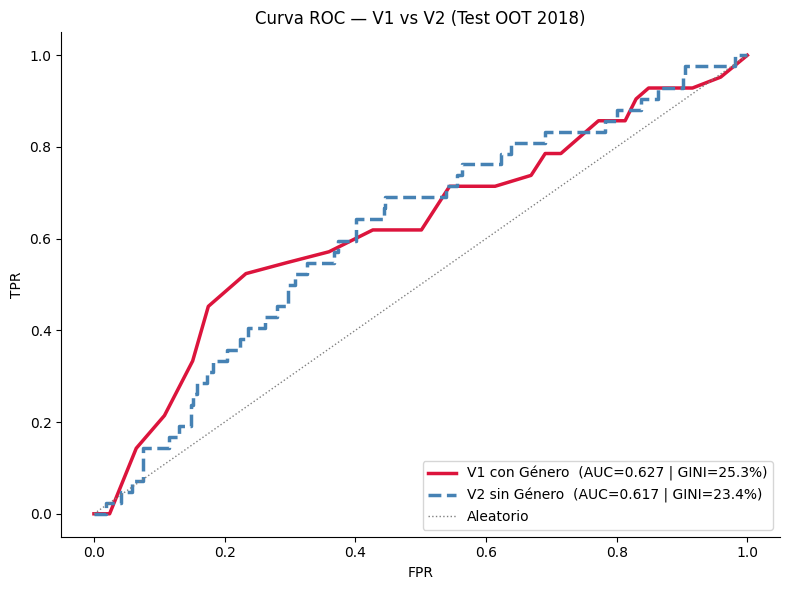

In [7]:
# ==============================================================================
# BLOQUE 7: AUDITORÍA SHAP, MODELO V2 Y COMPARACIÓN FINAL
# ==============================================================================
# Este bloque cumple tres objetivos:
#   1. Interpretar el Modelo V1 mediante SHAP para entender qué variables
#      están impulsando las decisiones del modelo (auditoría de explicabilidad).
#   2. Construir un Modelo V2 que excluye la variable Género para evaluar
#      el impacto en el rendimiento de operar bajo un estándar ético.
#   3. Comparar ambas versiones para fundamentar la recomendación final
#      a la gerencia.

import shap
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from category_encoders import TargetEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 7.1 Auditoría SHAP del Modelo V1 (con Género)
# ------------------------------------------------------------------------------
# SHAP (SHapley Additive exPlanations) descompone cada predicción en la
# contribución individual de cada variable, permitiendo identificar qué
# factores están pesando más en las decisiones del modelo. Es el estándar
# actual en explicabilidad de modelos de machine learning para finanzas.
print("--- Auditoría SHAP del Modelo V1 ---")

# Reconstrucción de los nombres de features tras el pipeline
preprocesador_v1 = pipeline_maestro.named_steps['matematicas']
feature_names_v1 = [
    name.replace('num__', '').replace('cat__', '')
    for name in preprocesador_v1.get_feature_names_out()
]

# Cálculo de valores SHAP sobre una muestra representativa del set de
# validación (1000 obs es suficiente para estabilidad del summary plot
# sin generar costo computacional excesivo).
explainer_v1   = shap.TreeExplainer(modelo_v1)
X_shap_v1      = X_val_processed[:1000]
shap_values_v1 = explainer_v1.shap_values(X_shap_v1)

# LightGBM binario puede devolver lista o array según la versión; se normaliza
if isinstance(shap_values_v1, list):
    shap_v1 = shap_values_v1[1]
else:
    shap_v1 = shap_values_v1

# Visualización 1: summary plot (beeswarm)
# Cada punto es una observación; el color indica el valor de la variable
# (rojo=alto, azul=bajo) y la posición horizontal indica el impacto en la
# predicción.
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_v1, X_shap_v1,
                   feature_names=feature_names_v1,
                   show=False, plot_size=(10, 7))
plt.title('SHAP V1 — Distribución del Impacto por Variable')
plt.tight_layout()
plt.show()

# Visualización 2: importancia media absoluta
# Métrica resumen que cuantifica cuánto pesa cada variable en promedio,
# resaltando en rojo las variables demográficas protegidas.
shap_importancia_v1 = pd.DataFrame({
    'Feature'   : feature_names_v1,
    'SHAP_mean' : np.abs(shap_v1).mean(axis=0)
}).sort_values('SHAP_mean', ascending=True).tail(15)

plt.figure(figsize=(9, 6))
colors_v1 = ['crimson' if 'Genero' in f or 'genero' in f.lower()
             else 'steelblue' for f in shap_importancia_v1['Feature']]
plt.barh(shap_importancia_v1['Feature'], shap_importancia_v1['SHAP_mean'],
         color=colors_v1, alpha=0.85)
plt.title('Importancia Media Absoluta SHAP — Modelo V1\n(rojo = variable demográfica protegida)')
plt.xlabel('|SHAP value| medio')
sns.despine()
plt.tight_layout()
plt.show()

# Cuantificación numérica del peso de Género en las decisiones del modelo
genero_features = [f for f in feature_names_v1
                    if 'Genero' in f or 'genero' in f.lower()]
if genero_features:
    peso_genero = shap_importancia_v1[
        shap_importancia_v1['Feature'].isin(genero_features)
    ]['SHAP_mean'].sum()
    peso_total = shap_importancia_v1['SHAP_mean'].sum()
    pct_genero = (peso_genero / peso_total) * 100
    print(f"\nPeso de Género en las decisiones del Modelo V1:")
    print(f"  SHAP medio absoluto      : {peso_genero:.4f}")
    print(f"  % del peso total visible : {pct_genero:.2f}%")
else:
    pct_genero = 0
    print("\nNo se encontraron features de Género en el modelo V1.")

# ------------------------------------------------------------------------------
# 7.2 Construcción del Modelo V2 (sin Género)
# ------------------------------------------------------------------------------
# Se replica la arquitectura del pipeline V1 excluyendo la variable Género.
# Los hiperparámetros óptimos se mantienen idénticos para aislar el efecto
# de la exclusión de Género (control experimental: si re-optimizara
# hiperparámetros, mezclaría dos cambios y no podría atribuir la diferencia
# de rendimiento a la exclusión de la variable).
print("\n--- Construcción del Modelo V2 (sin Género) ---")

# Eliminación de la variable protegida desde los DataFrames base
df_train_v2 = df_train.drop(columns=['Genero'], errors='ignore')
df_val_v2   = df_val.drop(columns=['Genero'],   errors='ignore')
df_test_v2  = df_2018.drop(columns=['Genero'],  errors='ignore')

# Re-identificación dinámica de columnas (sin Género)
cat_v2 = df_train_v2.select_dtypes(include=['object', 'category']).columns.tolist()
num_v2 = (df_train_v2
          .select_dtypes(include=[np.number])
          .columns
          .drop(variables_a_excluir, errors='ignore')
          .tolist())

# Pipeline V2 con la misma arquitectura que V1
preprocesador_v2 = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_v2 + ratios_cols),
        ('cat', TargetEncoder(min_samples_leaf=20, smoothing=10), cat_v2)
    ],
    remainder='drop'
)

pipeline_v2 = Pipeline(steps=[
    ('limpieza_actividad',  LimpiadorActividad()),
    ('agrupador_contratos', AgrupadorContratos()),
    ('agrupador_ocupacion', AgrupadorOcupacion()),
    ('ingenieria_ratios',   CreadorRatiosFinancieros()),
    ('matematicas',         preprocesador_v2)
])

# Procesamiento
X_train_v2 = pipeline_v2.fit_transform(df_train_v2, y_train)
X_val_v2   = pipeline_v2.transform(df_val_v2)
X_test_v2  = pipeline_v2.transform(df_test_v2)

print(f"Train V2 : {X_train_v2.shape}")
print(f"Val V2   : {X_val_v2.shape}")
print(f"Test V2  : {X_test_v2.shape}")

# Entrenamiento V2 con los mismos hiperparámetros óptimos del V1
dtrain_v2 = lgb.Dataset(X_train_v2, label=y_train)
dval_v2   = lgb.Dataset(X_val_v2,   label=y_val, reference=dtrain_v2)

modelo_v2 = lgb.train(
    best_params,
    dtrain_v2,
    num_boost_round=1000,
    valid_sets=[dtrain_v2, dval_v2],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)

print(f"\nModelo V2 entrenado.")
print(f"Iteraciones óptimas : {modelo_v2.best_iteration}")

# ------------------------------------------------------------------------------
# 7.3 Auditoría SHAP del Modelo V2
# ------------------------------------------------------------------------------
# Se verifica que tras eliminar Género, las decisiones del modelo se basen
# efectivamente en variables relacionadas con capacidad de pago e historial
# financiero.
print("\n--- Auditoría SHAP del Modelo V2 ---")

preprocesador_v2_step = pipeline_v2.named_steps['matematicas']
feature_names_v2 = [
    name.replace('num__', '').replace('cat__', '')
    for name in preprocesador_v2_step.get_feature_names_out()
]

explainer_v2   = shap.TreeExplainer(modelo_v2)
X_shap_v2      = X_test_v2[:1000]
shap_values_v2 = explainer_v2.shap_values(X_shap_v2)

if isinstance(shap_values_v2, list):
    shap_v2 = shap_values_v2[1]
else:
    shap_v2 = shap_values_v2

# Visualización: summary plot del modelo V2
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_v2, X_shap_v2,
                   feature_names=feature_names_v2,
                   show=False, plot_size=(10, 7))
plt.title('SHAP V2 — Decisiones Basadas en Variables de Capacidad de Pago')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 7.4 Comparación final V1 vs V2 sobre Test OOT
# ------------------------------------------------------------------------------
# Se evalúa el costo predictivo de excluir Género comparando GINI de ambos
# modelos sobre el mismo set de prueba bajo las mismas condiciones.
preds_v1_test = modelo_v1.predict(X_test_processed)
preds_v2_test = modelo_v2.predict(X_test_v2)

auc_v1  = roc_auc_score(y_test, preds_v1_test)
auc_v2  = roc_auc_score(y_test, preds_v2_test)
gini_v1 = (2 * auc_v1 - 1) * 100
gini_v2 = (2 * auc_v2 - 1) * 100

# Tabla comparativa
comparacion = pd.DataFrame({
    'Métrica': [
        'ROC-AUC (Test OOT)',
        'GINI (Test OOT)',
        'Variable Género incluida',
        'Riesgo regulatorio'
    ],
    'Modelo V1 (Con Género)': [
        f'{auc_v1:.4f}',
        f'{gini_v1:.2f}%',
        'Sí',
        'Alto'
    ],
    'Modelo V2 (Sin Género)': [
        f'{auc_v2:.4f}',
        f'{gini_v2:.2f}%',
        'No',
        'Bajo'
    ],
    'Diferencia': [
        f'{(auc_v1-auc_v2):+.4f}',
        f'{(gini_v1-gini_v2):+.2f} pts',
        '—',
        '—'
    ]
})

print("\n" + "=" * 70)
print("  RESUMEN COMPARATIVO: MODELO V1 vs MODELO V2")
print("=" * 70)
print(comparacion.to_string(index=False))
print("=" * 70)

# Visualización: curvas ROC superpuestas
fpr_v1, tpr_v1, _ = roc_curve(y_test, preds_v1_test)
fpr_v2, tpr_v2, _ = roc_curve(y_test, preds_v2_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_v1, tpr_v1, color='crimson', lw=2.5,
         label=f'V1 con Género  (AUC={auc_v1:.3f} | GINI={gini_v1:.1f}%)')
plt.plot(fpr_v2, tpr_v2, color='steelblue', lw=2.5, linestyle='--',
         label=f'V2 sin Género  (AUC={auc_v2:.3f} | GINI={gini_v2:.1f}%)')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':',
         label='Aleatorio')
plt.title('Curva ROC — V1 vs V2 (Test OOT 2018)')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

### Conclusión del bloque 7

**Auditoría de explicabilidad.** SHAP revela que `Genero` concentra el 26.86% del peso
predictivo total del modelo V1, por encima de variables de capacidad de pago como
`TiempoClienteMeses` o `PORCEND`. El análisis descriptivo muestra diferencias en tasa de mora
entre géneros con ingresos promedio prácticamente equivalentes, de modo que la señal no admite
una justificación causal financiera.

Su uso expone a la compañía en dos dimensiones. En lo normativo, la Ley 1581 de 2012 restringe
el tratamiento de datos sensibles y el uso de una variable cuyo efecto predictivo opera por
discriminación contraviene los principios de finalidad y proporcionalidad. En lo técnico,
introduce sesgo algorítmico sistemático que penaliza a clientes masculinos con perfil
financiero equivalente al femenino.

**Modelo V2.** Replica la arquitectura de V1 excluyendo `Genero` y conservando los mismos
hiperparámetros: el control experimental importa, porque re-optimizar mezclaría dos cambios e
impediría atribuir la diferencia de rendimiento a la exclusión de la variable. El costo
medido es de 1.96 puntos de GINI sobre la prueba OOT.

La conclusión operativa es que equidad algorítmica y viabilidad de negocio no se comportan
como objetivos mutuamente excluyentes.

**Consecuencia para la implementación.** Si V2 es el modelo que entra en producción, el
umbral debe recalcularse sobre sus propias predicciones: V1 y V2 son modelos distintos y
sus puntajes no viven en la misma escala. El bloque 10 documenta el problema y corrige el
corte.

**Advertencia para monitoreo.** El nivel académico queda en cuarto lugar de importancia y en
el contexto colombiano se correlaciona con nivel socioeconómico, por lo que puede operar como
proxy de una variable sensible. Se recomienda monitoreo trimestral de la tasa de aprobación
por nivel educativo.

--- Resumen de la Base de Competencia ---
[volumen y tasa de incumplimiento omitidos: describen la cartera de la entidad]
Periodo cubierto         : 2018-07 -> 2018-09

--- Completitud de Cobertura ---
Proveedor AB : 100.00% de la poblacion calificable
Proveedor XY : 88.78% de la poblacion calificable

--- Calculo de Metricas (con Bootstrap n=1000) ---

Proveedor AB:
  GINI         : -0.26%
  IC 95%       : [-0.91%, +0.38%]
  KS           : 0.0052
  Significativo: No (estadisticamente igual a aleatorio)

Proveedor XY:
  GINI         : +0.35%
  IC 95%       : [-0.35%, +1.03%]
  KS           : 0.0051
  Significativo: No (estadisticamente igual a aleatorio)

--- Estabilidad Temporal del Puntaje (Mensual) ---
[tabla omitida: contiene volumenes mensuales de la entidad]


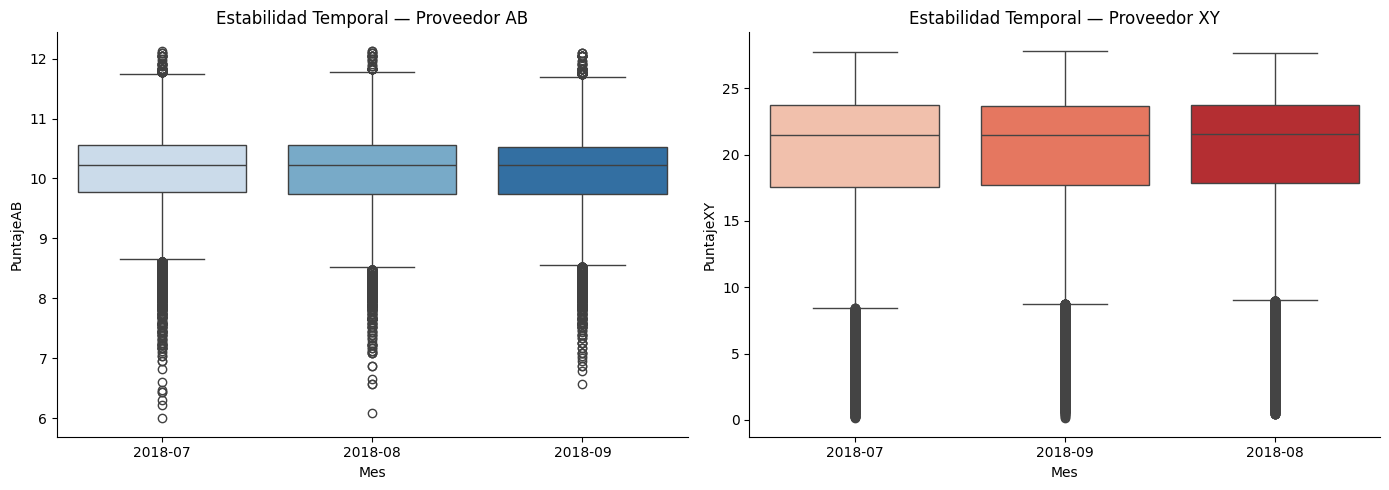

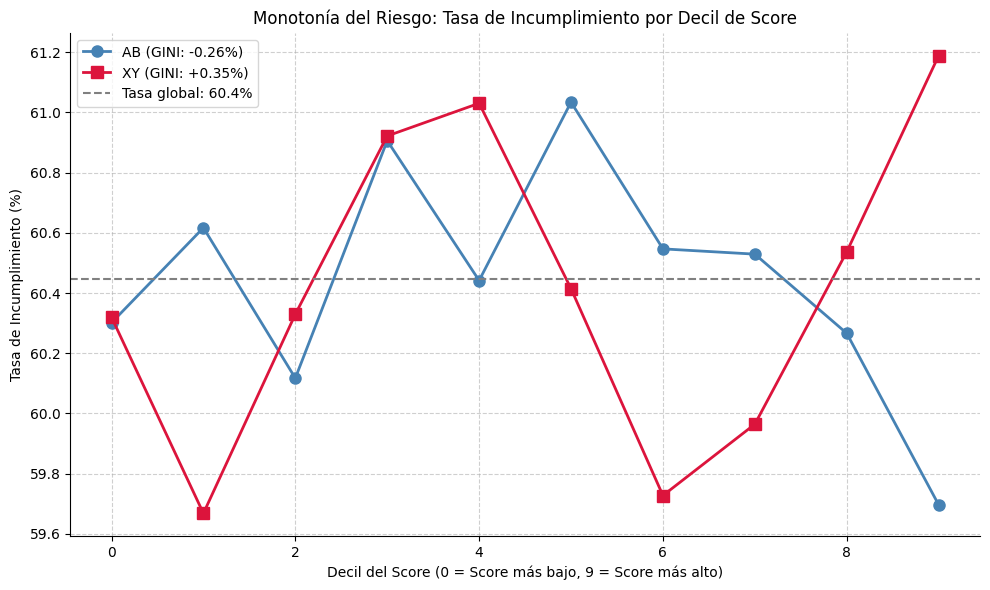

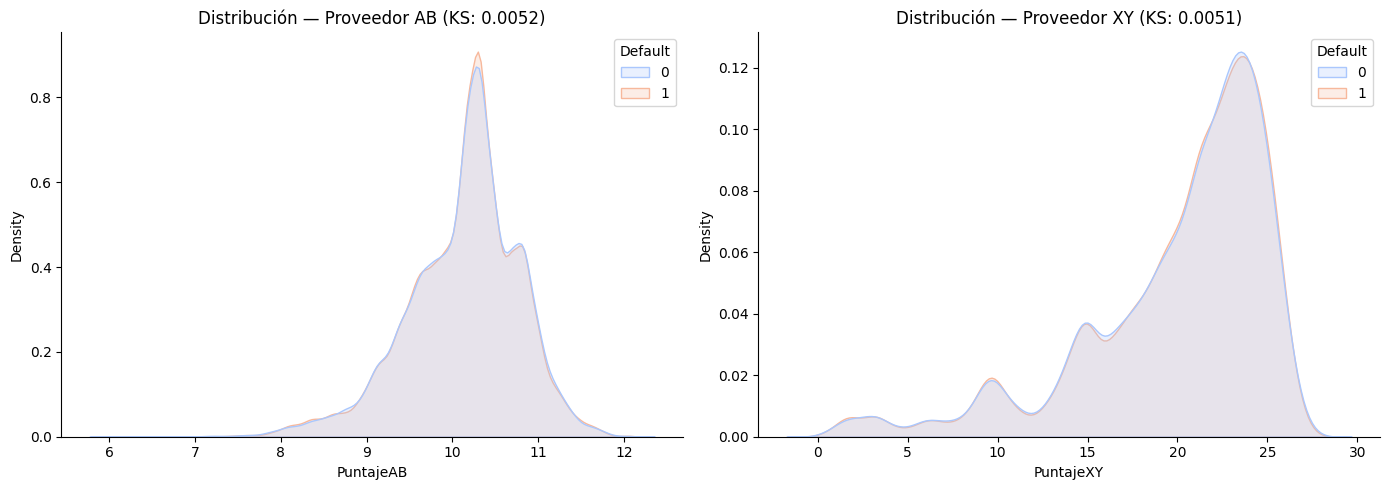


  COMPARATIVA FINAL DE PROVEEDORES
                            Métrica Proveedor AB Proveedor XY
                   GINI (con signo)       -0.26%       +0.35%
                       KS Statistic       0.0052       0.0051
           Completitud de cobertura      100.00%       88.78%
GINI estadísticamente significativo           No           No
       Capacidad discriminante real           No           No


In [8]:
# ==============================================================================
# BLOQUE 8: EVALUACIÓN DE PROVEEDORES EXTERNOS (BENCHMARKING)
# ==============================================================================
# Se comparan dos soluciones de scoring externas (Proveedor AB y Proveedor XY)
# para determinar su efectividad predictiva y estabilidad operativa.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# ------------------------------------------------------------------------------
# 8.1 Carga y limpieza de datos
# ------------------------------------------------------------------------------
# Se cargan los puntajes propuestos por los consultores. El Proveedor XY
# utiliza '.' como marcador de valores no calculados, por lo que se requiere
# coerción explícita a numérico (con NaN para los no convertibles).
ruta_competencia = r"../bases_datos/ModelosCompetencia.xlsx"
df_comp = pd.read_excel(ruta_competencia)

df_comp['PuntajeAB'] = pd.to_numeric(df_comp['PuntajeAB'], errors='coerce')
df_comp['PuntajeXY'] = pd.to_numeric(df_comp['PuntajeXY'], errors='coerce')

# Formateo temporal para análisis de estabilidad mensual
df_comp['Fecha Estudio'] = pd.to_datetime(
    df_comp['Fecha Estudio'].astype(str), format='%Y%m'
)

print("--- Resumen de la Base de Competencia ---")
print(f"Total clientes evaluados : {len(df_comp):,}")
print(f"Tasa de Default global   : {df_comp['Default'].mean()*100:.2f}%")
print(f"Periodo cubierto         : {df_comp['Fecha Estudio'].min().strftime('%Y-%m')} → "
      f"{df_comp['Fecha Estudio'].max().strftime('%Y-%m')}")

# ------------------------------------------------------------------------------
# 8.2 Análisis de completitud (estabilidad operativa)
# ------------------------------------------------------------------------------
# Se cuantifica qué porcentaje de la población puede ser calificada por cada
# proveedor. Una baja completitud implica que parte de los clientes quedaría
# sin score, generando un cuello de botella operativo en producción.
completitud_ab = df_comp['PuntajeAB'].notnull().mean()
completitud_xy = df_comp['PuntajeXY'].notnull().mean()

print("\n--- Completitud de Cobertura ---")
print(f"Proveedor AB : {completitud_ab*100:.2f}% de la población calificable")
print(f"Proveedor XY : {completitud_xy*100:.2f}% de la población calificable")

# ------------------------------------------------------------------------------
# 8.3 Cálculo de métricas de discriminación con prueba de significancia
# ------------------------------------------------------------------------------
# Se calculan GINI y KS preservando el signo original para detectar si el
# score discrimina en la dirección esperada. Adicionalmente se ejecuta un
# test de bootstrap para evaluar si el GINI es estadísticamente distinto
# de cero (modelo aleatorio).
def calcular_metricas_proveedor(df_eval, score_col, target_col='Default',
                                  n_bootstrap=1000, seed=42):
    """
    Calcula GINI, KS y prueba de significancia mediante bootstrap.
    GINI se reporta con su signo original (positivo = discrimina correctamente,
    negativo = discrimina al revés, cercano a 0 = no discrimina).
    """
    data = df_eval.dropna(subset=[score_col])
    y_true  = data[target_col].values
    y_score = data[score_col].values

    # AUC y GINI con signo original
    auc  = roc_auc_score(y_true, y_score)
    gini = (2 * auc) - 1

    # KS: distancia máxima entre distribuciones acumuladas de buenos y malos
    malos  = y_score[y_true == 1]
    buenos = y_score[y_true == 0]
    ks = ks_2samp(malos, buenos).statistic

    # Bootstrap para intervalo de confianza del GINI
    rng = np.random.default_rng(seed)
    ginis_boot = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        try:
            auc_b = roc_auc_score(y_true[idx], y_score[idx])
            ginis_boot.append((2 * auc_b) - 1)
        except ValueError:
            continue
    ic_inf = np.percentile(ginis_boot, 2.5)
    ic_sup = np.percentile(ginis_boot, 97.5)

    # Significancia: ¿el IC 95% incluye al cero?
    significativo = not (ic_inf <= 0 <= ic_sup)

    return {
        'gini'          : gini,
        'ks'            : ks,
        'ic_inf'        : ic_inf,
        'ic_sup'        : ic_sup,
        'significativo' : significativo,
        'n_evaluados'   : len(data)
    }

print("\n--- Cálculo de Métricas (con Bootstrap n=1000) ---")
metricas_ab = calcular_metricas_proveedor(df_comp, 'PuntajeAB')
metricas_xy = calcular_metricas_proveedor(df_comp, 'PuntajeXY')

print(f"\nProveedor AB (n={metricas_ab['n_evaluados']:,}):")
print(f"  GINI         : {metricas_ab['gini']*100:+.2f}%")
print(f"  IC 95%       : [{metricas_ab['ic_inf']*100:+.2f}%, {metricas_ab['ic_sup']*100:+.2f}%]")
print(f"  KS           : {metricas_ab['ks']:.4f}")
print(f"  Significativo: {'Sí' if metricas_ab['significativo'] else 'No (estadísticamente igual a aleatorio)'}")

print(f"\nProveedor XY (n={metricas_xy['n_evaluados']:,}):")
print(f"  GINI         : {metricas_xy['gini']*100:+.2f}%")
print(f"  IC 95%       : [{metricas_xy['ic_inf']*100:+.2f}%, {metricas_xy['ic_sup']*100:+.2f}%]")
print(f"  KS           : {metricas_xy['ks']:.4f}")
print(f"  Significativo: {'Sí' if metricas_xy['significativo'] else 'No (estadísticamente igual a aleatorio)'}")

# ------------------------------------------------------------------------------
# 8.4 Análisis de estabilidad temporal del puntaje
# ------------------------------------------------------------------------------
# Se evalúa si el comportamiento del score se mantiene consistente entre los
# meses cubiertos. Cambios bruscos en la media o desviación del score entre
# meses indicarían inestabilidad y haría imposible calibrar un punto de corte
# fijo en producción.
print("\n--- Estabilidad Temporal del Puntaje (Mensual) ---")

estabilidad_temporal = df_comp.groupby(df_comp['Fecha Estudio'].dt.to_period('M')).agg(
    N             = ('ID',           'count'),
    Tasa_Default  = ('Default',      'mean'),
    AB_media      = ('PuntajeAB',    'mean'),
    AB_std        = ('PuntajeAB',    'std'),
    XY_media      = ('PuntajeXY',    'mean'),
    XY_std        = ('PuntajeXY',    'std')
).round(3)
print(estabilidad_temporal.to_string())

# Visualización: distribución del score por mes para cada proveedor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_ab_clean = df_comp.dropna(subset=['PuntajeAB']).copy()
df_ab_clean['Mes'] = df_ab_clean['Fecha Estudio'].dt.strftime('%Y-%m')
sns.boxplot(data=df_ab_clean, x='Mes', y='PuntajeAB',
            ax=axes[0], palette='Blues')
axes[0].set_title('Estabilidad Temporal — Proveedor AB')
axes[0].set_ylabel('PuntajeAB')

df_xy_clean = df_comp.dropna(subset=['PuntajeXY']).copy()
df_xy_clean['Mes'] = df_xy_clean['Fecha Estudio'].dt.strftime('%Y-%m')
sns.boxplot(data=df_xy_clean, x='Mes', y='PuntajeXY',
            ax=axes[1], palette='Reds')
axes[1].set_title('Estabilidad Temporal — Proveedor XY')
axes[1].set_ylabel('PuntajeXY')

sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 8.5 Análisis de monotonía por deciles
# ------------------------------------------------------------------------------
# Se verifica que la tasa de incumplimiento aumente de forma consistente con
# el decil de riesgo asignado. Un modelo bien calibrado muestra una pendiente
# clara y monótona; un modelo aleatorio muestra una línea plana.
def obtener_analisis_deciles(df_eval, score_col, target_col='Default'):
    df_temp = df_eval.dropna(subset=[score_col]).copy()
    df_temp['Decil'] = pd.qcut(df_temp[score_col].rank(method='first'),
                                10, labels=False, duplicates='drop')
    return df_temp.groupby('Decil')[target_col].mean().reset_index()

deciles_ab = obtener_analisis_deciles(df_comp, 'PuntajeAB')
deciles_xy = obtener_analisis_deciles(df_comp, 'PuntajeXY')

plt.figure(figsize=(10, 6))
plt.plot(deciles_ab['Decil'], deciles_ab['Default']*100,
         marker='o', linewidth=2, markersize=8,
         label=f'AB (GINI: {metricas_ab["gini"]*100:+.2f}%)', color='steelblue')
plt.plot(deciles_xy['Decil'], deciles_xy['Default']*100,
         marker='s', linewidth=2, markersize=8,
         label=f'XY (GINI: {metricas_xy["gini"]*100:+.2f}%)', color='crimson')
plt.axhline(df_comp['Default'].mean()*100, color='gray', linestyle='--',
            label=f'Tasa global: {df_comp["Default"].mean()*100:.1f}%')
plt.title('Monotonía del Riesgo: Tasa de Incumplimiento por Decil de Score')
plt.xlabel('Decil del Score (0 = Score más bajo, 9 = Score más alto)')
plt.ylabel('Tasa de Incumplimiento (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 8.6 Distribución poblacional: solapamiento de buenos vs malos
# ------------------------------------------------------------------------------
# Se visualiza qué tanto se solapan las distribuciones de score entre buenos
# y malos clientes. Un buen modelo muestra distribuciones claramente separadas;
# un modelo aleatorio muestra solapamiento total.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_comp[df_comp['PuntajeAB'].notnull()],
            x='PuntajeAB', hue='Default',
            fill=True, common_norm=False, palette='coolwarm', ax=axes[0])
axes[0].set_title(f'Distribución — Proveedor AB (KS: {metricas_ab["ks"]:.4f})')

sns.kdeplot(data=df_comp[df_comp['PuntajeXY'].notnull()],
            x='PuntajeXY', hue='Default',
            fill=True, common_norm=False, palette='coolwarm', ax=axes[1])
axes[1].set_title(f'Distribución — Proveedor XY (KS: {metricas_xy["ks"]:.4f})')

sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 8.7 Resumen ejecutivo comparativo
# ------------------------------------------------------------------------------
resumen_proveedores = pd.DataFrame({
    'Métrica': [
        'GINI (con signo)',
        'KS Statistic',
        'Completitud de cobertura',
        'GINI estadísticamente significativo',
        'Capacidad discriminante real'
    ],
    'Proveedor AB': [
        f"{metricas_ab['gini']*100:+.2f}%",
        f"{metricas_ab['ks']:.4f}",
        f"{completitud_ab*100:.2f}%",
        'Sí' if metricas_ab['significativo'] else 'No',
        'Sí' if (metricas_ab['significativo'] and metricas_ab['gini'] > 0.10) else 'No'
    ],
    'Proveedor XY': [
        f"{metricas_xy['gini']*100:+.2f}%",
        f"{metricas_xy['ks']:.4f}",
        f"{completitud_xy*100:.2f}%",
        'Sí' if metricas_xy['significativo'] else 'No',
        'Sí' if (metricas_xy['significativo'] and metricas_xy['gini'] > 0.10) else 'No'
    ]
})

print("\n" + "=" * 60)
print("  COMPARATIVA FINAL DE PROVEEDORES")
print("=" * 60)
print(resumen_proveedores.to_string(index=False))
print("=" * 60)

### Conclusión del bloque 8

Ninguno de los dos proveedores demuestra capacidad discriminante estadísticamente
significativa. Los intervalos de confianza al 95% del GINI, estimados por bootstrap con 1.000
iteraciones, incluyen el cero en ambos casos: el desempeño observado es indistinguible de un
modelo aleatorio. El estadístico KS ronda 0.005 frente a un mínimo aceptable en la industria
del orden de 0.30.

El análisis de monotonía por deciles confirma el diagnóstico: ambas curvas son prácticamente
planas, oscilando dentro de un rango de apenas 1.5 puntos porcentuales, cuando un puntaje
funcional debería mostrar una pendiente clara y monótona.

La diferencia entre AB y XY es ruido muestral, no superioridad técnica. Contratar a AB por su
mayor cobertura implicaría pagar por un servicio sin valor predictivo. La recomendación es no
contratar en las condiciones actuales y renegociar exigiendo recalibración sobre la población
objetivo, documentación técnica de variables y metodología, y pilotos sobre muestras
controladas.

Como limitación, la base de evaluación presenta una tasa de incumplimiento muy elevada, lo que
sugiere preselección hacia clientes de alto riesgo y podría explicar parcialmente el resultado.
Tampoco se dispone de documentación técnica de los proveedores, lo que impide diagnosticar las
causas del bajo desempeño.

## Bloque 9 — Curva de política de corte

Los bloques anteriores entregan un modelo y un umbral recomendado. Este bloque convierte esa
recomendación en un objeto consultable: la relación completa entre el umbral de decisión y sus
consecuencias operativas, para los modelos V1 y V2.

La métrica central es `mora_aprobados`, la tasa de incumplimiento observada dentro de la
población que el umbral aprueba. Es la cifra que determina si una política es sostenible, y no
aparece en las métricas de discriminación habituales.

El archivo exportado contiene únicamente tasas agregadas —sin registros ni conteos absolutos—
por lo que puede distribuirse junto con el repositorio.

In [9]:
# ==============================================================================
# BLOQUE 9: EXPORTACIÓN DE LA CURVA DE POLÍTICA DE CORTE
# ==============================================================================
# Se recorre el rango de umbrales de decisión y se registran, para cada uno,
# las métricas operativas resultantes sobre el conjunto out-of-time. El
# barrido se aplica a los modelos V1 y V2 para permitir la comparación
# directa del costo operativo de excluir la variable protegida.
#
# El archivo resultante contiene solo tasas agregadas: no incluye registros
# individuales ni conteos absolutos de la cartera.

import numpy as np
import pandas as pd

def barrido_umbrales(y_true, y_score, etiqueta_modelo, paso=0.005):
    """Calcula metricas operativas para un rango de umbrales de decision."""
    umbrales = np.round(np.arange(0.02, 0.605, paso), 4)
    filas = []

    for t in umbrales:
        rechazado = y_score >= t
        aprobado = ~rechazado

        tp = int(((y_true == 1) & rechazado).sum())
        fp = int(((y_true == 0) & rechazado).sum())
        fn = int(((y_true == 1) & aprobado).sum())

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (2 * precision * recall / (precision + recall)
              if (precision + recall) else 0.0)

        filas.append({
            "modelo": etiqueta_modelo,
            "umbral": float(t),
            "tasa_aprobacion": float(aprobado.mean()),
            "mora_aprobados": float(y_true[aprobado].mean()) if aprobado.sum() else 0.0,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(filas)

y_true_oot = np.asarray(y_test)

curva = pd.concat([
    barrido_umbrales(y_true_oot, np.asarray(preds_prob_test), "V1 (con Genero)"),
    barrido_umbrales(y_true_oot, np.asarray(preds_v2_test), "V2 (sin Genero)"),
], ignore_index=True).round(5)

curva.to_csv("../curva_politica_corte.csv", index=False)

# Referencias que la capa de visualizacion necesita para contextualizar la curva:
# la mora base es el resultado de aprobar a todos, es decir, no usar modelo.
mora_base = float(y_true_oot.mean())

print(f"Curva exportada: {curva.shape[0]} filas ({curva['modelo'].nunique()} modelos)")
print(f"Mora base sin modelo (aprobar a todos): {mora_base:.5f}")
print(f"Umbral F1     : {umbral_f1:.4f}")
print(f"Umbral Youden : {umbral_youden:.4f}")

Curva exportada: 234 filas (2 modelos)
Mora base sin modelo (aprobar a todos): 0.09150
Umbral F1     : 0.1306
Umbral Youden : 0.1296


## Bloque 10 — Corrección del punto de corte para el modelo V2

El corte definido en el bloque 6 se calculó sobre las predicciones de validación del modelo
V1. La recomendación final del análisis, sin embargo, es implementar V2. Ambos son modelos
distintos y sus puntajes no comparten escala, de modo que trasladar el umbral de uno al otro
no es válido.

Este bloque cuantifica el error y recalcula el corte sobre las predicciones de validación de
V2, aplicando los mismos dos criterios, para que la recomendación operativa sea ejecutable.

In [10]:
# ==============================================================================
# BLOQUE 10: CORRECCIÓN DEL PUNTO DE CORTE PARA EL MODELO V2
# ==============================================================================
# El umbral del bloque 6 proviene de la validación del modelo V1. Dado que la
# recomendación es implementar V2, el corte debe recalcularse sobre las
# predicciones de ese modelo: V1 y V2 producen distribuciones de puntaje
# distintas y un umbral no es transferible entre ellas.

import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve, confusion_matrix

# ------------------------------------------------------------------------------
# 10.1 Magnitud del error al trasladar el umbral de V1 a V2
# ------------------------------------------------------------------------------
aprobados_heredado = (preds_v2_test < umbral_youden).mean()

print("--- Umbral de V1 aplicado a V2 sobre Test OOT ---")
print(f"Umbral heredado    : {umbral_youden:.4f}")
print(f"Tasa de aprobación : {aprobados_heredado*100:.2f}%")
print("El umbral de V1 cae por debajo del rango de puntajes de V2, "
      "por lo que rechazaría a la totalidad de la población.")

# ------------------------------------------------------------------------------
# 10.2 Recálculo sobre la validación de V2
# ------------------------------------------------------------------------------
# Se replica el procedimiento del bloque 6 sin ninguna variación metodológica:
# el umbral se estima sobre validación y se evalúa sobre la prueba OOT.
preds_v2_val = modelo_v2.predict(X_val_v2)

precision_v2, recall_v2, thr_pr_v2 = precision_recall_curve(y_val, preds_v2_val)
fpr_v2_val, tpr_v2_val, thr_roc_v2 = roc_curve(y_val, preds_v2_val)

n_pr = len(thr_pr_v2)
f1_v2 = np.divide(
    2 * precision_v2[:n_pr] * recall_v2[:n_pr],
    precision_v2[:n_pr] + recall_v2[:n_pr],
    out=np.zeros(n_pr),
    where=(precision_v2[:n_pr] + recall_v2[:n_pr]) > 0
)
umbral_f1_v2 = thr_pr_v2[int(np.argmax(f1_v2))]

n_roc = min(len(thr_roc_v2), len(tpr_v2_val), len(fpr_v2_val))
youden_v2 = tpr_v2_val[:n_roc] - fpr_v2_val[:n_roc]
umbral_youden_v2 = thr_roc_v2[:n_roc][int(np.argmax(youden_v2))]

print("\n--- Umbrales recalculados sobre la validación de V2 ---")
print(f"Máximo F1-Score : {umbral_f1_v2:.4f}")
print(f"Máximo Youden J : {umbral_youden_v2:.4f}")

# ------------------------------------------------------------------------------
# 10.3 Punto de operación resultante sobre Test OOT
# ------------------------------------------------------------------------------
# Se incorpora la tasa de mora observada dentro de la población aprobada, que
# es la magnitud que determina la sostenibilidad de la política y no aparece
# en las métricas de discriminación.
mora_base = float(np.mean(y_test))

filas = []
for nombre, modelo_scores, umbral in [
    ("V1 @ Youden V1", preds_prob_test, umbral_youden),
    ("V1 @ F1 V1",     preds_prob_test, umbral_f1),
    ("V2 @ Youden V2", preds_v2_test,   umbral_youden_v2),
    ("V2 @ F1 V2",     preds_v2_test,   umbral_f1_v2),
]:
    rechazado = modelo_scores >= umbral
    aprobado = ~rechazado
    tn, fp, fn, tp = confusion_matrix(y_test, rechazado.astype(int)).ravel()
    filas.append({
        "Política": nombre,
        "Umbral": round(float(umbral), 4),
        "Aprobación %": round(float(aprobado.mean()) * 100, 1),
        "Mora aprobados %": round(float(np.mean(np.asarray(y_test)[aprobado])) * 100, 2)
                            if aprobado.sum() else np.nan,
        "Recall": round(tp / (tp + fn), 3) if (tp + fn) else 0.0,
    })

comparativa = pd.DataFrame(filas)
print("\n--- Punto de operación sobre Test OOT ---")
print(f"Mora base sin modelo (aprobar a todos): {mora_base*100:.2f}%\n")
print(comparativa.to_string(index=False))

# ------------------------------------------------------------------------------
# 10.4 Exportación de los umbrales recomendados
# ------------------------------------------------------------------------------
pd.DataFrame([{
    "mora_base_oot": round(mora_base, 5),
    "umbral_f1_v1": round(float(umbral_f1), 4),
    "umbral_youden_v1": round(float(umbral_youden), 4),
    "umbral_f1_v2": round(float(umbral_f1_v2), 4),
    "umbral_youden_v2": round(float(umbral_youden_v2), 4),
}]).to_csv("../umbrales_recomendados.csv", index=False)

print("\nUmbrales exportados a ../umbrales_recomendados.csv")

--- Umbral de V1 aplicado a V2 sobre Test OOT ---
Umbral heredado    : 0.1296
Tasa de aprobación : 0.00%
El umbral de V1 cae por debajo del rango de puntajes de V2, por lo que rechazaría a la totalidad de la población.

--- Umbrales recalculados sobre la validación de V2 ---
Máximo F1-Score : 0.4532
Máximo Youden J : 0.4532

--- Punto de operación sobre Test OOT ---
Mora base sin modelo (aprobar a todos): 9.15%

      Política  Umbral  Aprobación %  Mora aprobados %  Recall
V1 @ Youden V1  0.1296          42.9              6.09   0.714
    V1 @ F1 V1  0.1306          44.0              5.94   0.714
V2 @ Youden V2  0.4532          77.8              7.56   0.357
    V2 @ F1 V2  0.4532          77.8              7.56   0.357

Umbrales exportados a ../umbrales_recomendados.csv


### Conclusión del bloque 10

**El umbral heredado no era aplicable.** El corte de 0.1296, calculado sobre la validación de V1,
cae por debajo del rango de puntajes de V2 y rechaza a la totalidad de la población. La
recomendación original del análisis —implementar V2 con ese corte— habría detenido la originación
por completo.

**El óptimo estadístico de V2 tampoco es la política adecuada.** Recalculado sobre su propia
validación, el umbral óptimo de V2 es 0.4532, y los criterios de F1 y Youden coinciden en ese
mismo valor. Su punto de operación sobre la prueba OOT:

| | V2 @ 0.4532 (óptimo estadístico) | V2 @ 0.3350 |
|---|---|---|
| Tasa de aprobación | 77.8% | 42.0% |
| Recall sobre morosos | 35.7% | 73.8% |
| Mora en aprobados | 7.56% | 5.70% |

Contra una mora base de 9.15% si se aprueba a todos. En su óptimo, V2 deja pasar dos tercios de
los morosos y reduce la mora en apenas 1.6 puntos: es un criterio bien calculado y una política
pobre para un producto cuyo objetivo declarado es evitar pérdidas por mala originación.

Dos razones para no adoptarlo. La primera es conceptual: Youden maximiza la suma de sensibilidad y
especificidad, lo que asume implícitamente que un falso positivo y un falso negativo cuestan lo
mismo. En originación no es así — otorgar a un moroso cuesta el capital, rechazar a un buen cliente
cuesta el margen. La segunda es empírica: que ambos criterios caigan exactamente en el mismo valor
sobre 772 registros de validación sugiere un único escalón dominante en la curva, no un óptimo
robusto.

**Recomendación.** El umbral no lo fija un estadístico sino el apetito de riesgo, y la curva
exportada en el bloque 9 es el instrumento para negociarlo. En 0.3350, V2 reproduce el punto de
operación de V1 con mejor perfil de riesgo: aprueba al 42% y reduce la mora del 9.15% al 5.70%.
Ese es el punto defendible frente a Riesgo y frente a Negocio.

Sobre 459 registros de prueba con alrededor de 42 morosos, las diferencias de uno o dos puntos de
recall equivalen a un puñado de créditos y caen dentro del ruido muestral. Lo que sí es robusto es
la diferencia estructural entre 36% y 74% de recall.